In [1]:
%%capture

!pip install geopandas;
!pip install branca;
!pip install folium>=0.12;
!pip install mapclassify;
!pip install osmnx;
!pip install rasterio;
!pip install rasterstats;
!pip install contextily

In [2]:
import dask.dataframe as dd
from dask.diagnostics import ProgressBar

import geopandas as gpd
import pandas as pd

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import plotly.tools as tls
from matplotlib import cm
import matplotlib.dates as mdates

import contextily as ctx

from itertools import combinations
from scipy.stats import pearsonr, spearmanr
import numpy as np

In [3]:
import matplotlib as mpl

mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["legend.frameon"] = False

pd.set_option("display.max_columns", None)

In [4]:
base_path = "s3://wbgggscecovid19dev-mobility/proposals/561/"
save_folder = "STAGE1_EDA_Manila"

FROM_DATE = pd.to_datetime("2023-01-01")
TO_DATE = pd.to_datetime("2023-12-31")


DATES_TO_ANALYZE = pd.date_range(start=FROM_DATE, end=TO_DATE, freq="d")
print(len(DATES_TO_ANALYZE),"days to analyze.")

365 days to analyze.


In [5]:
# PLOTTING FUNCTIONS
from matplotlib.colors import LogNorm

def plot_hourly_doy_heatmap(
    df,
    value_col="n_points",
    year=None,
    log_scale=False,
    figsize=(18, 6),
    cmap="viridis"
):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["doy"] = df["date"].dt.dayofyear

    if year is None:
        year = df["date"].dt.year.iloc[0]

    n_days = 366 if pd.Timestamp(year=year, month=12, day=31).dayofyear == 366 else 365
    heat = np.full((24, n_days), np.nan)

    heat[df["hour"].astype(int), df["doy"] - 1] = df[value_col]

    fig, ax = plt.subplots(figsize=figsize)
    cmap = plt.get_cmap(cmap).copy()
    cmap.set_bad("white")

    im = ax.imshow(
        heat,
        aspect="auto",
        cmap=cmap,
        norm=LogNorm(vmin=1, vmax=np.nanmax(heat)) if log_scale else None
    )

    ax.set_yticks(range(24))
    ax.set_ylabel("Hour")

    ax.set_xticks(np.linspace(0, n_days - 1, 12, dtype=int))
    ax.set_xticklabels(
        [pd.Timestamp(year=year, month=m, day=1).strftime("%b") for m in range(1, 13)]
    )
    ax.set_xlabel("Month")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(value_col)

    #ax.set_title(f"Hourly activity heatmap ({year})")

    return fig, ax, cbar



def plot_hourly_profiles(
    df,
    measures=("n_points", "n_users", "n_hexes"),
    plot_day_lines=False,
    plot_average=True,
    show_iqr=False,
    center="mean",              # "mean" or "median"
    figsize=(7, 7),
    iqr_color="lightblue",
    iqr_alpha=0.4
):
    assert center in {"mean", "median"}, "center must be 'mean' or 'median'"

    measure_to_label = {"n_users": "Active users",
                   "n_hexes_active": "Visited hexes",
                   "n_points": "GPS observations"}

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(measures),
        figsize=figsize,
        constrained_layout=True,
        gridspec_kw={"hspace": 0.1, "wspace": 0}
    )

    measure_to_label = {"n_users": "Active users",
                   "n_hexes": "Visited hexes",
                   "n_points": "GPS observations"}

    if len(measures) == 1:
        axes = [axes]

    for ax, measure in zip(axes, measures):

        # Spaghetti (per-day lines)
        if plot_day_lines:
            df_daily = return_daily_series_measure(df, measure, groupby_col="hour")
            for vector in df_daily[measure]:
                ax.plot(vector, color="lightblue", alpha=0.2)

        # IQR cloud (always based on quantiles)
        if show_iqr:
            q = (
                df.groupby("hour")[measure]
                  .quantile([0.25, 0.75])
                  .unstack()
            )
            ax.fill_between(
                np.arange(24),
                q[0.25],
                q[0.75],
                color=iqr_color,
                alpha=iqr_alpha,
                label="IQR",
                linewidth=0
            )

        # Center line (mean or median)
        if plot_average:
            if center == "mean":
                stats = df.groupby("hour")[measure].agg(["mean", "std"])
                ax.errorbar(
                    np.arange(24),
                    stats["mean"],
                    stats["std"],
                    color="k",
                    marker="o",
                    linewidth=1,
                    elinewidth=1,
                    label="Mean ± std"
                )
            else:  # median
                med = df.groupby("hour")[measure].median()
                ax.plot(
                    np.arange(24),
                    med,
                    color="k",
                    marker="o",
                    linewidth=1,
                    label="Median",
                    markersize=5
                )

        ax.set_ylabel(measure_to_label[measure], weight=600)
        ax.set_xlabel("Hour", weight=600)

        # Cosmetics
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xticks(range(1,24,2))

    return fig, axes



In [6]:
import pandas as pd
import numpy as np

def fill_time_gaps(x, y, freq="D"):
    # convert to pandas objects
    x = pd.to_datetime(x)
    y = np.asarray(y)

    # build series
    s = pd.Series(y, index=x)

    # full date range
    full_index = pd.date_range(start=s.index.min(),end=s.index.max(),freq=freq)

    # reindex -> missing dates become NaN
    s_filled = s.reindex(full_index)

    return s_filled.index, s_filled.values


In [7]:
def return_daily_series_measure(df, measure, groupby_col="hour"):

    df_ts = df.pivot_table(index='date', columns=groupby_col, values=measure, aggfunc='first', observed=False)
    df_ts = df_ts.reindex(columns=range(24)).sort_index(axis=1)
    df_ts = df_ts.apply(lambda row: row.tolist(), axis=1).rename(f'{measure}').reset_index()
    df_ts[f'{measure}'] = df_ts[f'{measure}'].apply(lambda x: [0 if pd.isna(v) else v for v in x])
    
    return df_ts

In [8]:
import numpy as np

def gini(values):
    values = np.asarray(values, dtype=float)
    values = values[values >= 0]  # safety
    values = np.sort(values)

    n = len(values)
    if n == 0:
        return np.nan

    index = np.arange(1, n + 1)
    return (2 * np.sum(index * values) / (n * np.sum(values))) - (n + 1) / n


In [9]:
def plot_map_gdf(gdf, col, log_transform=True, figsize=(10, 10),
    cmap="Blues", alpha=1, ax=None, fig=None, th=0,
    show_cbar=True, vmin=None, vmax=None, cbar_orientation="horizontal"):

    # Filter data
    plot_gdf = gdf[gdf[col] > th].copy()

    # Apply transformation
    if log_transform:
        plot_gdf["_plot_val"] = np.log10(1 + plot_gdf[col])
        label = f"log10(1 + {col})"
        transform = lambda x: np.log10(1 + x)
    else:
        plot_gdf["_plot_val"] = plot_gdf[col]
        label = col
        transform = lambda x: x

    values = plot_gdf["_plot_val"]

    # Create figure/axis if needed
    if ax is None and fig is None:
        fig, ax = plt.subplots(figsize=figsize)

    # Determine coherent vmin/vmax in transformed space
    if vmin is None:
        vmin_plot = values.min()
    else:
        vmin_plot = transform(vmin)

    if vmax is None:
        vmax_plot = values.max()
    else:
        vmax_plot = transform(vmax)

    # Plot map using SAME normalization
    plot_gdf.plot(
        column="_plot_val",
        cmap=cmap,
        legend=False,
        ax=ax,
        alpha=alpha,
        vmin=vmin_plot,
        vmax=vmax_plot,
    )

    cbar = None

    # Create matching colorbar
    if show_cbar:
        norm = plt.Normalize(vmin=vmin_plot, vmax=vmax_plot)
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm._A = []

        cbar = fig.colorbar(sm, ax=ax, fraction=0.015, pad=0.1, orientation=cbar_orientation)
        cbar.set_label(label)

    return fig, ax, cbar   


In [10]:
import matplotlib.ticker as mtick

def thousands_formatter(x, pos):

    if abs(x) >= 1000:
        val = x / 1000
        # only show decimal if not whole number
        if val.is_integer():
            return f"{int(val)}k"
        else:
            return f"{val:.1f}k"
    else:
        return str(int(x))

## TODO
- 1.1
- 7.4

- swap T1 and T2 labels
- general improvement
- general polishing
- add cover figure
- 



## Data Loading

1. Temporal dataset (day, hour)
2. User Dataset (day, uid)
3. User Summary Dataset (daily aggregated info on users)
4. Spatial Dataset (day, hex_id)
5. Spatial Summary Dataset (daily aggregated info on hexes)



#### 1. Temporal dataset (hour level)

**Load temporal daily stats** <br>
`| date | hour | n_points | n_users | n_hexes |`

In [12]:
%%time
paths = [f"{base_path}{save_folder}/temporal_stats/date={d:%Y-%m-%d}/*.parquet" for d in DATES_TO_ANALYZE]

with ProgressBar():
    df_temporal = (
        dd.read_parquet(paths, columns=['date', 'hour', 'n_points', 'n_users', 'n_hexes'],
                        storage_options={"profile": "ECA"}).compute())

df_temporal["date"] = pd.to_datetime(df_temporal["date"], errors="coerce").astype("datetime64[ns]")

[########################################] | 100% Completed | 4.05 sms
CPU times: user 5.14 s, sys: 350 ms, total: 5.49 s
Wall time: 14.7 s


#### 2. User Dataset (heavy)

**Load users info** <br>
_approx loading time: 2 min_ <br>
_approx memory usage: 27 GB_

In [102]:
%%time
paths_user_profile = [f"{base_path}{save_folder}/user_stats/date={d.strftime('%Y-%m-%d')}/*.parquet" for d in DATES_TO_ANALYZE]
ddf_users = dd.read_parquet(paths_user_profile, storage_options = {"profile": "ECA"})

with ProgressBar():
    df_users = ddf_users.compute()
    df_users["date"] = pd.to_datetime(df_users["date"], errors="coerce").astype("datetime64[ns]")

[########################################] | 100% Completed | 142.18 s
CPU times: user 2min 25s, sys: 1min 24s, total: 3min 50s
Wall time: 2min 41s


In [103]:
mem_bytes = df_users.memory_usage(deep=True).sum()
mem_gb = mem_bytes / (1024**3)
print(f"{mem_gb:.2f} GB")

27.09 GB


#### 3. User Summary Dataset

**Load user daily summary** <br>


In [13]:
%%time
paths_user_daily_summary = [f"{base_path}{save_folder}/user_daily_summary/date={d.strftime('%Y-%m-%d')}/*.parquet" for d in DATES_TO_ANALYZE]
ddf_user_daily_summary = dd.read_parquet(paths_user_daily_summary, storage_options = {"profile": "ECA"})

with ProgressBar():
    df_user_daily_summary = ddf_user_daily_summary.compute()
    df_user_daily_summary["date"] = pd.to_datetime(df_user_daily_summary["date"], errors="coerce").astype("datetime64[ns]")

    # add day of the week
    df_user_daily_summary["dow"] = df_user_daily_summary["date"].dt.dayofweek
    df_user_daily_summary["is_weekend"] = df_user_daily_summary["dow"] >= 5

[########################################] | 100% Completed | 3.95 sms
CPU times: user 5.15 s, sys: 279 ms, total: 5.43 s
Wall time: 12.7 s


#### 4. Spatial dataset (h3 res 7 level)

**Load spatial profile** <br>
`| date | hex_id | n_points | n_users |`

In [14]:
%%time
paths_spatial_profile = [f"{base_path}{save_folder}/spatial_stats/date={d.strftime('%Y-%m-%d')}/*.parquet" for d in DATES_TO_ANALYZE]
#columns = ['date', 'hour', 'n_points', 'n_users', 'n_hexes']
ddf_spatial = dd.read_parquet(paths_spatial_profile, storage_options = {"profile": "ECA"})

with ProgressBar():
    df_spatial = ddf_spatial.compute()
    df_spatial["date"] = pd.to_datetime(df_spatial["date"], errors="coerce").astype("datetime64[ns]")

[########################################] | 100% Completed | 4.21 sms
CPU times: user 5.02 s, sys: 514 ms, total: 5.53 s
Wall time: 14 s


In [14]:
df_spatial[:1]

,hex_id,n_points,n_users,date
0,88694e5201fffff,145,23,2023-01-01


#### 5. Spatial Summary Dataset

**Load spatial daily summary** <br>


In [15]:
%%time
paths_spatial_daily_summary = [f"{base_path}{save_folder}/spatial_daily_summary/date={d.strftime('%Y-%m-%d')}/*.parquet" for d in DATES_TO_ANALYZE]
ddf_spatial_daily_summary = dd.read_parquet(paths_spatial_daily_summary, storage_options = {"profile": "ECA"})

with ProgressBar():
    df_spatial_daily_summary = ddf_spatial_daily_summary.compute()
    df_spatial_daily_summary["date"] = pd.to_datetime(df_spatial_daily_summary["date"], errors="coerce").astype("datetime64[ns]")

[########################################] | 100% Completed | 3.99 sms
CPU times: user 5.3 s, sys: 334 ms, total: 5.64 s
Wall time: 12.3 s


#### 6. Auxiliary files

In [16]:
### Load the spatial tessellation (Uber H3)

gdf_h3 = gpd.read_file("./spatial_tessellations/H3_tess_manila_res8.gpkg", layer="H3_tess")

# Manila: Exploratory Data Analysis and a Quality Assessment Report

(updated one)

## 1. Overview


This analysis presents an Exploratory Data Analysis (EDA) and a Quality Assessment (QA) of large-scale mobility data collected in the Philippines in 2023, specifically focusing on the **Metro Manila area**. The EDA aims to uncover key characteristics of the dataset, such as its temporal dynamics, spatial distribution, and patterns of user activity. Building on these insights, the QA component assesses the dataset’s coverage, temporal stability, and representativeness, while identifying potential structural biases and limitations that could affect downstream analytical and policy applications. The analysis is conducted primarily at an aggregate level, focusing on identifying systematic trends within the data rather than reconstructing individual mobility behaviors.

<div style="color: red">
<img src="https:/"
     width="600"
     style="display: block; margin: 0 auto;">
</div>

### 1.1 Executive Summary

The analyzed dataset contains approximately **4.4 billion GPS observations** from **27.18 million users** during 2023, with **high overall temporal coverage (96.62%)**.
<div style="color: red">

OLD VERSION (WAS FOR TURKEY)
    
**Overall assessment:**
The dataset is suitable for constructing aggregate, presence-based indicators of urban space usage, particularly in urban and peri-urban areas. However, its use requires explicit treatment of temporal regime shifts, uneven spatial coverage, and strong heterogeneity in user activity.
___
#### **Key Findings**

**1. Temporal dynamics are affected by changes in data capture intensity.**

The dataset is stable for most of the year but exhibits three anomalous intervals:
 _(i)_ a mid-year increase in tracking intensity per user,
 _(ii)_ a sharp decline in active user coverage, and
 _(iii)_ a year-end surge in total volume.

In addition, a 13-day data gap in September introduces a structural discontinuity. These shifts reflect changes in data generation rather than clear behavioral mobility changes and must be treated explicitly in longitudinal analysis.

**2. Spatial coverage is highly uneven and concentrated in urban areas.**

Mobility observations are strongly clustered in metropolitan regions and follow a heavy-tailed spatial distribution. A small fraction of spatial units accounts for a disproportionately large share of observations, while many rural and peripheral areas exhibit persistently low activity.

Population–mobility alignment is substantially stronger in dense urban areas than in rural regions, indicating systematic underrepresentation of sparsely populated zones.

**3. User activity is highly heterogeneous and daily traces are sparse.**

User contributions follow a heavy-tailed pattern: a small subset of highly active users generates a large share of observations, while most users contribute limited and localized daily traces.

As a result, the dataset is structurally more robust as a **presence signal** than as a basis for detailed individual mobility reconstruction.


____

#### **Implications for Policy Use**

Taken together, these findings indicate that the dataset should be interpreted primarily as a **coverage and presence indicator**, not as a complete representation of individual mobility behavior.

Accordingly:

1. **Temporal comparisons require normalization.**
   Raw time-series comparisons across different data regimes are not valid without adjusting for variations in user coverage and tracking intensity.

2. **Spatial aggregation is necessary outside urban cores.**
   Fine-grained inference in low-activity areas is statistically unstable and should be avoided unless spatially aggregated or population-adjusted.

3. **Individual-level mobility metrics require strong aggregation.**
   Trajectory-based indicators are sensitive to user sparsity and contribution inequality and should not be used without filtering or normalization.


Overall, the dataset is well suited for aggregate, presence-based analyses of urban space usage at daily or coarser temporal resolution, particularly in urban and peri-urban areas. However, **longitudinal analyses require particular caution**: direct comparisons across time periods may reflect changes in sampling intensity or user coverage rather than real changes in mobility or space usage. Accordingly, analyses should:

_(i)_ exclude or explicitly model anomalous periods,
_(ii)_ avoid comparing metrics across periods with different data capture regimes unless appropriately normalized, and
_(iii)_ avoid fine-grained inference in low-activity spatial units.

**Importantly, the dataset does not support the construction of a full-year baseline of the Urban Space Usage Index**, as regime shifts in tracking intensity and user coverage would introduce structural breaks unrelated to underlying spatial dynamics. A valid annual baseline must therefore be derived from temporally stable regimes or constructed using explicit normalization procedures to ensure interpretability and comparability over time.

</div>

## 2. Context and Objectives

This analysis is conducted to generate high-frequency indices of urban space use (e.g., retail centers, construction sites, manufacturing zones, financial centers, residential areas). These indicators aim to inform policy-relevant analyses of urban activity, resilience, and responses to external shocks, including major events and climate-related disruptions.

The analysis focuses primarily on the spatial dimension of the data. Mobility observations generated by individuals are used to characterize aggregate patterns of activity across locations rather than to reconstruct individual mobility trajectories. Users are therefore treated as proxies for mobility intensity and the relative popularity of places, rather than as units of behavioral inference.

Accordingly, the EDA and QA prioritize the assessment of aggregate, presence-based spatial signals, with particular attention to coverage, temporal stability, and sensitivity to spatial and temporal aggregation choices. User-level trajectory analyses are explicitly outside the scope of this evaluation.

The findings of this assessment directly inform methodological decisions in subsequent project phases, including the selection of spatial resolution, normalization strategies, and temporal smoothing procedures used to construct the Urban Space Usage Index.

## 3. Dataset Overview

The mobility dataset used in this analysis is the **[Veraset Movement dataset](https://docs.datapartnership.org/partners/veraset/examples/veraset.html)**, provided by Veraset as part of the Mobility Data collection from the Development Data Partnership. This dataset consists of anonymized, high-frequency mobile device location pings collected through a network of mobile applications and software development kits (SDKs). Each record captures a device's geographic coordinates (latitude and longitude), a UTC timestamp indicating when the observation was recorded, and a device identifier.

For this particular study, the analysis focuses on mobility patterns in **[Metro Manila (Philippines)](https://en.wikipedia.org/wiki/Metro_Manila)** during the year **2023**, using the dataset to examine spatial and temporal movement dynamics within the metropolitan region.

### 3.1 Data Sources and Structure

The dataset is collected and stored at a **daily granularity** and includes the following fields:

* **`uid`** *(string)*: Unique identifier of the user
* **`datetime`** *(datetime, UTC)*: Timestamp of the observation, recorded in UTC
* **`hex_id`** *(string)*: H3 spatial index at **resolution 7**
* **`latitude`** *(float)*: Latitude coordinate
* **`longitude`** *(float)*: Longitude coordinate
* **`country`** *(category)*: Country code


A preliminary check confirms that the **`country` field is constant and equal to `PH`** for all records, indicating that the dataset corresponds to a single national context and that this variable does not contribute to analytical variability. While the original dataset covers the entire **Philippines**, this analysis focuses specifically on the **Metro Manila** metropolitan area. Therefore, during the data loading process, only observations located within the geographic boundaries of **Metro Manila** are retained for the analysis.

All timestamps are reported in **UTC** and must be converted to the appropriate **local time zone** before performing any time-based analysis. After conversion, records associated with a given partition date may shift to the **previous or following local calendar day**, depending on the time zone. In addition, a small subset of records may exhibit minor **temporal offsets** due to signal transmission delays. Furthermore, as specified in Veraset’s data documentation, the data feed may include observations from adjacent dates up to **three days after the nominal delivery date**. For example, events captured on January 1 (based on `utc_timestamp`) may appear in data feeds distributed between January 1 and January 4.

To properly account for both time zone conversion effects and feed delivery lags, it is therefore necessary to load data ranging from **one day prior to up to three days after** the target date to ensure that all relevant records are captured.




### 3.2 Dataset Statistics

<div style="text-align: center;">
  <div style="display: inline-block; max-width: 100%; overflow-x: auto; text-align: left;">
      
| **Metric** | **Value** |
|:----------:|:---------:|
| **Total GPS points** | 4.4 billion |
| **Total users** | 27.18 million |
| **Total active areas** | 1041 |
| **Time span** | Jan-Dec 2023 |
| **Missing days** | January 1st and September 18th 3 AM - 30th 3 AM)
| **Spatial unit** | Default H3 res 7; analyzed at res 8 for finer urban-scale analysis (lat/lng; aggregable to any H3 resolution). |
| **Temporal coverage** | 96.62% |
| **Spatial coverage** | 99.52%|
| **Avg. points / day** | 12,426,375 |
| **Avg. users / day** | 733,539 |
| **Avg. hexes / day** | 869 |
    
</div>
</div>

In [17]:
print(round(np.mean(df_user_daily_summary["n_points"]),0))
print(round(np.mean(df_user_daily_summary["n_users"]),0))
print(round(np.mean(df_spatial_daily_summary["n_hexes_active"]),0))

12426375.0
733539.0
869.0


In [19]:
total_gps_points = df_user_daily_summary["n_points"].sum()
min_date = df_user_daily_summary["date"].min()
max_date = df_user_daily_summary["date"].max()
n_days = df_user_daily_summary["date"].nunique()
total_users = df_users["uid"].nunique()
total_areas = df_spatial["hex_id"].nunique()

print(f"Total GPS points: {round(total_gps_points/1e6, 2)} million")
print(f"Total GPS points: {round(total_gps_points/1e9, 2)} billions")
print(f"Total users: {round(total_users/1e6, 2)} million")
print(f"Total active areas: {total_areas}")

print(f"{n_days} days | from {min_date} to {max_date}")

#missing_days = list(set(DATES_TO_ANALYZE) - set(df_spatial_daily_summary["date"]))
#missing_days.sort()
#print(f"There are {len(missing_days)+1} missing days: ",  [d.strftime("%Y-%m-%d") for d in missing_days])
missing_day_start = pd.to_datetime("2023-09-18")
missing_day_end = pd.to_datetime("2023-09-30")

Total GPS points: 4398.94 million
Total GPS points: 4.4 billions
Total users: 0.0 million
Total active areas: 1041
354 days | from 2023-01-01 00:00:00 to 2023-12-31 00:00:00


In [ ]:
A = list(df_user_daily_summary["date"].unique())

In [ ]:
# create full expected range (hourly example)
full_range = pd.date_range(start=min(A), end=max(A))
len(full_range)

In [ ]:
missing = full_range.difference(A)

print(missing)

In [20]:
missing_day_start = pd.to_datetime("2023-09-18")
missing_day_end = pd.to_datetime("2023-09-30 23:59:59")

### 3.3 Dataset Temporal Coverage

We assess the temporal coverage of the dataset relative to the 2023 calendar year. Overall temporal coverage is high, with observations available for **96.62% of all days and hours** in 2023 (Figure 1).


**Two explicit data gaps are identified.** First, observations are missing on **January 1st between 00:00 until 08:00**, corresponding to the beginning of the year. Second, a continuous interruption in the data occurs from **September 18th at 08:00 to September 30th at 03:00**, amounting to a 13-day gap. Because September 18th and September 30th contain only partial observations (8 and 16 hours, respectively), both days are excluded to ensure consistency in daily aggregation. Consequently, the period **September 18th to September 30th (inclusive)** is treated as missing in the daily analysis. For the same reason, **January 1st** is also excluded, as it contains incomplete observations.
We recommend treating September 18–30 as structurally missing and avoiding interpolation across this interval in time-series analyses, as it introduces a discontinuity in the data-generating process.

Outside of these periods, the dataset contains observations for every day and hour of the year.

In [21]:
pd.to_datetime("2023-09-18 00:00") - pd.to_datetime("2023-09-30 23:59:59")

Timedelta('-13 days +00:00:01')

In [22]:
n_covered_slots = len(df_temporal.groupby(["date", "hour"], as_index=False).mean())
pct_coverage = 100*n_covered_slots/(24*365)
print(f"temporal coverage: {round(pct_coverage,2)}%")

temporal coverage: 96.62%


In [23]:
len(df_temporal[df_temporal["date"] == pd.to_datetime("2023-09-18")])

8

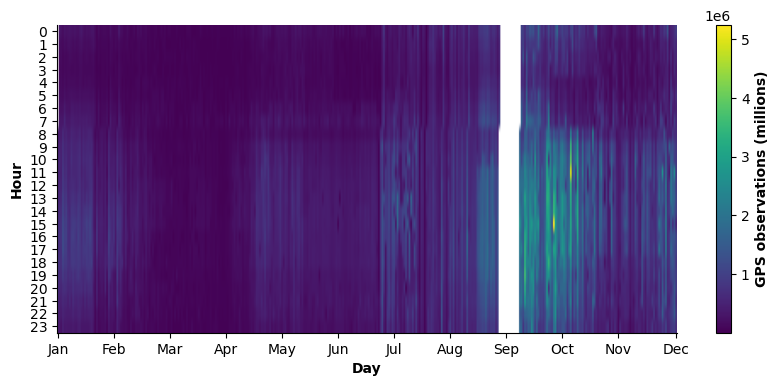

In [24]:
fig, ax, cbar = plot_hourly_doy_heatmap(df_temporal, value_col="n_points", figsize=(10, 4))
cbar.set_label("GPS observations (millions)", weight=600)
ax.set_xlabel("Day", weight=600)
ax.set_ylabel("Hour", weight=600);

**Figure 1.** Heatmap showing the total number of GPS points recorded for each hour of the day across the calendar year. The colorbar represents the absolute number of GPS observations (in millions), with lighter shades indicating higher volumes. White areas indicate periods with no recorded observations. 

In [ ]:
### clean dataset by removing "partial" days (i.e., 2023-09-18 00:00 - 2023-09-30 00:00)

In [25]:
df_temporal = df_temporal[df_temporal["date"] != pd.to_datetime("2023-09-18 00:00")]
df_temporal = df_temporal[df_temporal["date"] != pd.to_datetime("2023-09-30 00:00")]

#df_users = df_users[df_users["date"] != pd.to_datetime("2023-09-18 00:00")]
#df_users = df_users[df_users["date"] != pd.to_datetime("2023-09-30 00:00")]

df_user_daily_summary = df_user_daily_summary[df_user_daily_summary["date"] != pd.to_datetime("2023-09-18 00:00")]
df_user_daily_summary = df_user_daily_summary[df_user_daily_summary["date"] != pd.to_datetime("2023-09-30 00:00")]

df_spatial = df_spatial[df_spatial["date"] != pd.to_datetime("2023-09-18 00:00")]
df_spatial = df_spatial[df_spatial["date"] != pd.to_datetime("2023-09-30 00:00")]

df_spatial_daily_summary = df_spatial_daily_summary[df_spatial_daily_summary["date"] != pd.to_datetime("2023-09-18 00:00")]
df_spatial_daily_summary = df_spatial_daily_summary[df_spatial_daily_summary["date"] != pd.to_datetime("2023-09-30 00:00")]

### 3.4 Dataset Spatial Coverage

The dataset provides coverage of **Metro Manila** at the latitude–longitude level and is aggregated by default to **H3 hexagons at resolution 7**. For the purposes of this analysis, the data are re-aggregated to **H3 resolution 8** (corresponding to an average cell area of approximately 0.73 km²) in order to better capture spatial variation within a dense urban environment. Given the availability of latitude–longitude coordinates, the dataset can be flexibly aggregated to any H3 spatial resolution.

**Spatial coverage** is defined as the share of H3 hexagons covering the study area that record at least one observation during the year. Under this definition, the spatial coverage of the dataset is **99.52%**. To ensure that observations located near administrative boundaries are properly captured, the study area was extended using a small spatial buffer around **Metro Manila**. As a result, the dataset achieves **near-complete spatial coverage**, effectively approximating full coverage of the metropolitan area.


In [26]:
100*len(df_spatial.groupby("hex_id")) / len(gdf_h3)

99.52198852772466

In [27]:
df_hex_avg_points_day = df_spatial.groupby("hex_id", as_index=False).mean()
gdf_map_spatial_coverage = gdf_h3.merge(df_hex_avg_points_day, left_on="h3_index", right_on="hex_id", how="left")
gdf_map_spatial_coverage["n_points"] = gdf_map_spatial_coverage["n_points"].fillna(0)

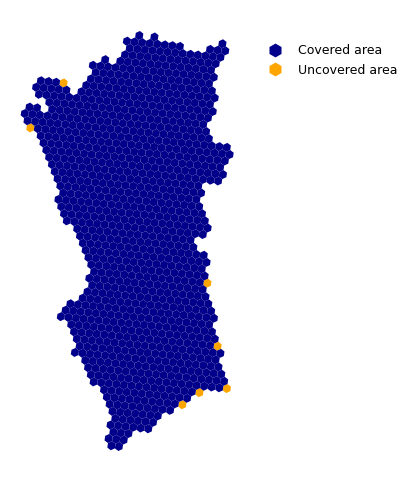

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6), sharex=True)

gdf_map_spatial_coverage[gdf_map_spatial_coverage["n_points"]==0].plot(ax=ax, color="orange", edgecolor=None)
gdf_map_spatial_coverage[gdf_map_spatial_coverage["n_points"]>0].plot(ax=ax, color="darkblue", edgecolor=None)
ax.axis("off")

# Hexagon legend markers
legend_elements = [
    Line2D(
        [0], [0],
        marker='h',
        color='none',
        markerfacecolor='darkblue',
        markeredgecolor='none',
        markeredgewidth=0,
        markersize=10,
        label='Covered area',
    ),
    Line2D(
        [0], [0],
        marker='h',
        color='none',
        markerfacecolor='orange',
        markeredgecolor='none',
        markeredgewidth=0,
        markersize=10,
        label='Uncovered area',
    )
]

ax.legend(handles=legend_elements, fontsize=9, bbox_to_anchor=(1.7, .95), bbox_transform=ax.transAxes);


#fig, ax = plot_map_gdf(gdf_map_spatial_coverage[:1000], col="n_points", cmap="Blues", fig=fig, ax=ax[1])
#ax.set_title("Avg. points per hex (1y)");
#ax[1].axis("off");

**Figure 2.** Spatial coverage of H3 hexagons (resolution 7) in Türkiye, 2023. Hexagons that record at least one GPS observation during the year are shown in blue. Hexagons with no recorded observations are shown in orange. Spatial coverage is defined as the share of H3 hexagons with at least one observation over the study period.

## 4. Spatial Data Quality Assessment

This section examines the spatial dimension of the mobility dataset by analyzing spatial coverage, concentration, and sparsity across H3 hexagonal units. The analysis focuses on the distribution of observations and users across space, the degree of spatial inequality, and the relationship between observed users and resident population.

### 4.1 Spatial Distribution

The map on the left in Figure 7 shows the spatial distribution of mobility observations collected throughout 2023 across the metropolitan area of Manila. Data are aggregated on an H3 hexagonal grid (resolution 8) and expressed as the average number of points per hexagon over the year.

As expected for an urban area, observations are concentrated across all the area of interest. Areas with the fewest observations (lighter colors) include the natural area "La Mesa Watershed" in the northeast, and water bodies such as Laguna de Bay in the southeast (map on the right). The presence of points over water bodies is likely due to individuals carrying GPS-enabled devices while traveling by ferry, boat, or ship, and these points will need to be addressed in subsequent steps of the analysis.

In [29]:
df_hex_avg_points_day = df_spatial.groupby("hex_id", as_index=False).mean()
gdf_map_spatial_coverage = gdf_h3.merge(df_hex_avg_points_day, left_on="h3_index", right_on="hex_id", how="left")
gdf_map_spatial_coverage["n_points"] = gdf_map_spatial_coverage["n_points"].fillna(0)

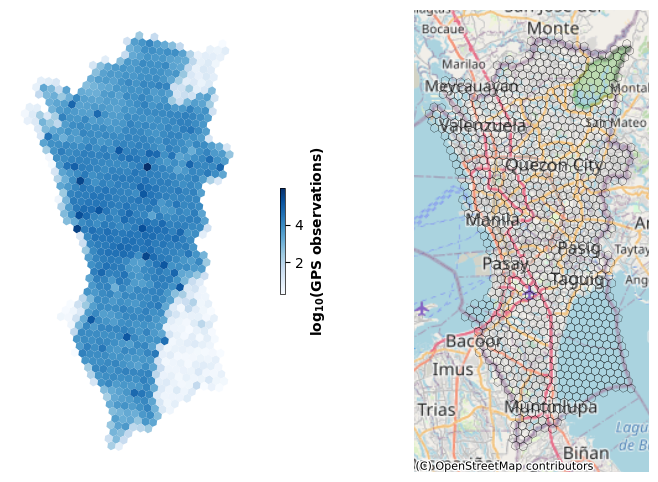

In [30]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6), sharex=False)

_, _, cbar = plot_map_gdf(gdf_map_spatial_coverage, col="n_points", cmap="Blues",
                          vmin=1, fig=fig, ax=axes[0], cbar_orientation="vertical")
cbar.set_label(r"$\mathbf{log_{10}}$(GPS observations)", weight=600)
cbar.outline.set_linewidth(0.5)   


gdf_map_spatial_coverage.to_crs(epsg=3857).plot(
    ax=axes[1],  facecolor="none",  edgecolor="k",linewidth=.2)

ctx.add_basemap(axes[1], source=ctx.providers.OpenStreetMap.Mapnik, zoom=10)

axes[0].axis("off");
axes[1].axis("off");

**Figure 7.** (left) Spatial distribution of GPS observations shown as the *average annual number of records per H3 hexagon (resolution 8)*. Higher values represent a greater concentration of recorded activity. The color scale is log₁₀-transformed, with darker blue tones indicating areas with more observations. (right) H3 hexagon grid overlaid on an OpenStreetMap (OSM) base map for spatial reference.


### 4.2 Total Points and Unique Users per Visited Spatial Unit

Each spatial unit corresponds to an H3 hexagon at resolution 8 (see the figure below for an illustrative example). Overall, daily activity at the hex level is generally high. On average, each hexagon contains approximately 14,300 points generated by 1,370 users. However, these averages are influenced by highly active locations: the median values are lower, with a hexagon containing 5,166 points generated by 288 users. The difference between the mean and the median indicates a right-skewed spatial distribution of activity.

In [31]:
round(gdf_map_spatial_coverage, 0).sort_values("n_points", ascending=False)[:1].explore(tooltip=["h3_index", "n_points"]);

In [32]:
df_spatial_gb_avg = df_spatial.groupby(["date", "hex_id"], observed=True, as_index=False).mean()

dict_SDS_mean = df_spatial_daily_summary.mean().to_dict()
print("--- Averages per hex per day ---")
print("measure")
print("avg. points:\t", round(df_spatial_gb_avg["n_points"].mean(), 2))
print("avg. users:\t", round(df_spatial_gb_avg["n_users"].mean(), 2))

print()
df_spatial_gb_median = df_spatial.groupby(["date", "hex_id"], observed=True, as_index=False).median()
print("--- Medians per hex per day ---")
print("median points:\t", round(df_spatial_gb_median["n_points"].median(), 2))
print("median users:\t", round(df_spatial_gb_median["n_users"].median(), 2))

--- Averages per hex per day ---
measure
avg. points:	 14256.98
avg. users:	 1369.36

--- Medians per hex per day ---
median points:	 5164.0
median users:	 389.0


The time series of the points-per-hexagon and users-per-hexagon metrics (Figure 8, left and right panels, respectively) shows the presence of different regimes throughout the year. In particular, several time intervals display a marked decrease in both the number of GPS observations per hexagon and the number of active users per hexagon. 

During these intervals, the aggregate number of GPS points and active users remains comparable to other periods. The decline in the per-hexagon metrics therefore does not appear to be driven by a reduction in overall activity. Instead, it suggests a **strong spatial imbalance**, where observations become concentrated in a small number of highly visited hexagons.

For reference, notable periods include: 1-20 march, 9-12 july, 27 july-20 august.

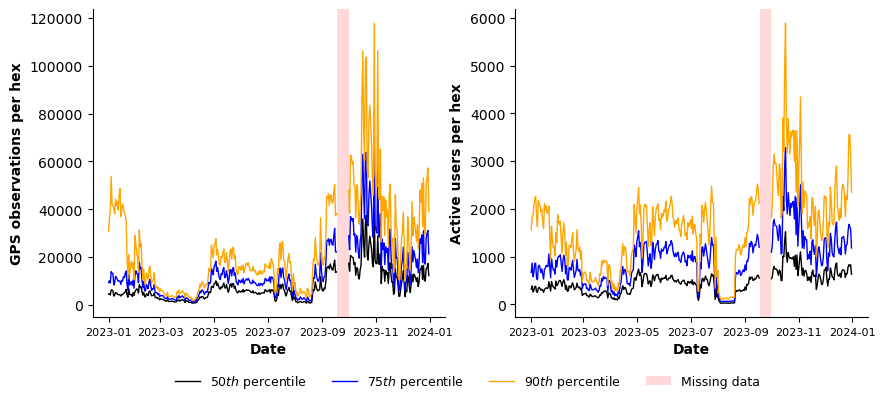

In [33]:
colors = ["k", "blue", "orange"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharex=False)

# points
cols = ["p50_points_hex", "p75_points_hex", "p90_points_hex"]
#cols = ["p50_points_hex"]

for col, color in zip(cols, colors):

    label = f"{int(col[1:3])}$th$ percentile"    
    x_points, y_points = fill_time_gaps(df_spatial_daily_summary["date"], df_spatial_daily_summary[col], freq="D")
    axes[0].plot(x_points, y_points, c=color, label=label, linewidth=1)

axes[0].set_xlabel("Date", weight=600)
axes[0].set_ylabel("GPS observations per hex", weight=600)
axes[0].axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0, label="Missing data")

# users
cols = cols = ["p50_users_hex", "p75_users_hex", "p90_users_hex"]
for col, color in zip(cols, colors):
    x_users, y_users = fill_time_gaps(df_spatial_daily_summary["date"], df_spatial_daily_summary[col], freq="D")
    axes[1].plot(x_users, y_users, c=color, linewidth=1)

axes[1].set_xlabel("Date", weight=600)
axes[1].set_ylabel("Active users per hex", weight=600)
axes[1].axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0)

axes[0].tick_params(axis='x', labelsize=8)
axes[1].tick_params(axis='x', labelsize=8)

fig.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),   # centered between the two axes
    bbox_transform=fig.transFigure,
    ncol=4,
    frameon=False,
    fontsize=9
);

**Figure 8.** Daily values of points per hexagon (left) and users per hexagon (right). The black line represents the 50th percentile (median), the blue line the 75th percentile, and the orange line the 90th percentile. The shaded area indicates periods of missing data.

In [34]:
#### Dynamic version of the previous one (to zoom in)
plotly_fig = tls.mpl_to_plotly(fig)
#plotly_fig.show()
plotly_fig.write_html("A.html")

/opt/conda/lib/python3.12/site-packages/plotly/matplotlylib/renderer.py:609: UserWarning:

I found a path object that I don't think is part of a bar chart. Ignoring.



To further investigate this phenomenon, we analyze the distribution of observations across hexagons using **Lorenz curves**. The curves computed for the anomalous periods and for a baseline period show that, during the anomalous intervals, observations are substantially more concentrated in a small number of hexagons. This is reflected by **higher Gini coefficients**, indicating stronger spatial inequality in the distribution of visits.

One exception is the **period in March**, which exhibits a Gini coefficient comparable to that of a reference period, in this case May 2023. The lower values of the per-hexagon metrics are consistent with a **general reduction in activity**, as both the number of active users and the total number of GPS observations decrease during this interval (see Figure 3). Consequently, the lower averages observed in this period are expected and do not appear to result from increased spatial concentration of visits.

Although this pattern will be explored in more detail in the following subsection, the preliminary evidence suggests that these regimes should be interpreted with caution. In particular, shifts in the distribution of visits across hexagons may reflect **changes in sampling or spatial coverage**, rather than genuine changes in mobility behavior.

To assess whether the observed patterns could instead be explained by real-world events affecting mobility, we also investigated potential **exogenous events** occurring in the metropolitan area of Manila during the identified periods. However, no major events were found that could plausibly account for the observed concentration of observations. For example, no significant events were recorded in August 2023 that could explain the changes observed during the **2023-07-27 - 2023-08-20** interval.

In **Section 5.3**, we examine the spatial distribution of observations by identifying the hexagons that account for a large share of activity during these anomalous periods.

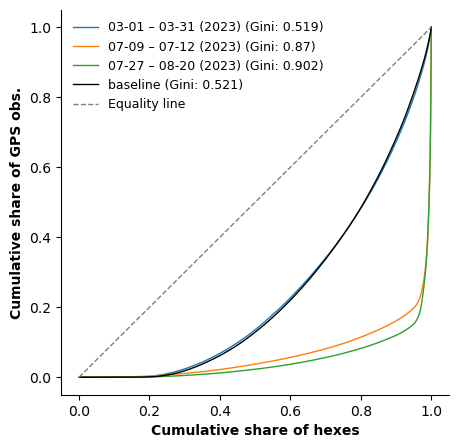

In [35]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

unusual_ranges = [[pd.to_datetime("2023-03-01"), pd.to_datetime("2023-03-31")],
                [pd.to_datetime("2023-07-09"), pd.to_datetime("2023-07-12")],
                 [pd.to_datetime("2023-07-27"), pd.to_datetime("2023-08-20")]]

baseline = [pd.to_datetime("2023-05-01"), pd.to_datetime("2023-05-31")]

for date_range in unusual_ranges:
    df_spatial_range = df_spatial[df_spatial["date"].between(date_range[0], date_range[1])]
    df_spatial_range = df_spatial_range.groupby(["hex_id"], as_index=False).agg(n_points=("n_points", "mean"))

    # aggregated curve
    values = np.sort(df_spatial_range["n_points"].values)
    cum_points = np.cumsum(values)
    cum_points = cum_points / cum_points[-1]

    cum_hexes = np.arange(1, len(values) + 1) / len(values)
    gini_score = round(gini(values), 3)

    label = f"{date_range[0]:%m-%d} – {date_range[1]:%m-%d} (2023)"
    
    ax.plot(cum_hexes, cum_points, label=f"{label} (Gini: {gini_score})", linewidth=1)


df_spatial_range = df_spatial[df_spatial["date"].between(baseline[0], baseline[1])]
df_spatial_range = df_spatial_range.groupby(["hex_id"], as_index=False).agg(n_points=("n_points", "mean"))

# aggregated curve
values = np.sort(df_spatial_range["n_points"].values)
cum_points = np.cumsum(values)
cum_points = cum_points / cum_points[-1]

cum_hexes = np.arange(1, len(values) + 1) / len(values)
gini_score = round(gini(values), 3)

label = f"{date_range[0]:%m-%d} – {date_range[1]:%m-%d} (2023)"

ax.plot(cum_hexes, cum_points, label=f"baseline (Gini: {gini_score})", c="k", linewidth=1)
    


ax.plot([0, 1], [0, 1], "--", color="gray", label="Equality line", linewidth=1)
ax.set_xlabel("Cumulative share of hexes", weight=600)
ax.set_ylabel("Cumulative share of GPS obs.", weight=600)
ax.legend(loc="upper left", fontsize=9);

**Figure X.** Lorenz curves of the distribution of GPS observations across hexagons for selected time intervals in 2023, compared with a baseline period. The dashed line represents the line of perfect equality.

### 4.3 Inequality of Distribution of Observations across Spatial Units


We analyze the distribution of observations across spatial units (H3 hexes) to assess the degree of spatial inequality, as most hexes receive relatively few observations, while a small fraction accumulates a disproportionately large share of GPS points.

This inequality is apparent in both the rank‑frequency distribution (Figure 9, left), which exhibits a heavy‑tailed pattern, and in the Lorenz curve (Figure 9, right), with an associated Gini coefficient of 0.657, reflecting strong spatial concentration of activity in a limited number of hexes. Such levels of inequality are typical in human mobility data, where visit frequencies are known to follow heavy‑tailed distributions. Empirical analyses of large-scale GPS and mobile phone datasets consistently show that most locations are infrequently visited, while a few highly attractive locations capture the majority of visits {cite}`gonzalez2008understanding, barbosa2018human`.

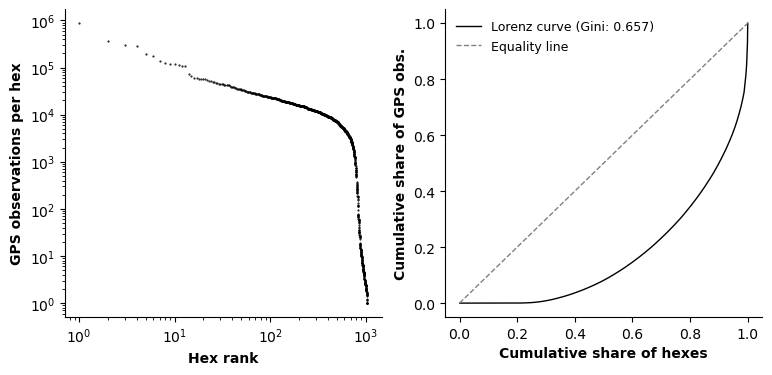

In [36]:
df_spatial_gb_avg = df_spatial.groupby(["hex_id"], as_index=False).agg(n_points=("n_points", "mean"))
df_spatial_gb_avg = df_spatial_gb_avg.sort_values("n_points", ascending=False)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

# Rank
ranks = np.arange(1, len(df_spatial_gb_avg) + 1)
values = df_spatial_gb_avg["n_points"].values

#Rank–size plot (log–log)
axes[0].loglog(ranks, values, c="k", marker=".", linestyle="none", markersize=1)
axes[0].set_xlabel("Hex rank", weight=600)
axes[0].set_ylabel("GPS observations per hex", weight=600)

# Lorenz curve

# aggregated curve
values = np.sort(df_spatial_gb_avg["n_points"].values)
cum_points = np.cumsum(values)
cum_points = cum_points / cum_points[-1]

cum_hexes = np.arange(1, len(values) + 1) / len(values)
gini_score = round(gini(values), 3)
axes[1].plot(cum_hexes, cum_points, label=f"Lorenz curve (Gini: {gini_score})", c="k", linewidth=1)
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Equality line", linewidth=1)
axes[1].set_xlabel("Cumulative share of hexes", weight=600)
axes[1].set_ylabel("Cumulative share of GPS obs.", weight=600)
#ax[1].set_title("Lorenz curve of GPS points per hex")
axes[1].legend(loc="upper left", fontsize=9)

#for ax in axes:
#    ax.set_aspect('equal')

**Figure 9.** Rank-size distribution of total GPS observations per H3 hexagon, illustrating a pronounced heavy-tailed distribution (left).
Lorenz curve showing the cumulative share of observations by ranked hexagons (right), with the corresponding Gini coefficient (0.66) quantifying the high degree of spatial inequality in activity concentration.

We further characterize spatial inequality by examining the share of total observations captured by the most frequently visited hexes. The results shown in Figure 10 highlight that the top 1% of hexes consistently account for about 10% of all GPS points during the first part of the year. However, following the change in data collection regime on 9 July, we observe a pronounced peak, indicating that observations became highly concentrated in a few popular hexes. For example, in late August, the top 1% of hexes accounted for approximately 60% of all observations, reflecting an extreme concentration of activity.

These fluctuations across data collection regimes suggest that such periods should be carefully considered in subsequent analyses, particularly by excluding high-regime intervals where the top 1% of hexes dominate the dataset.

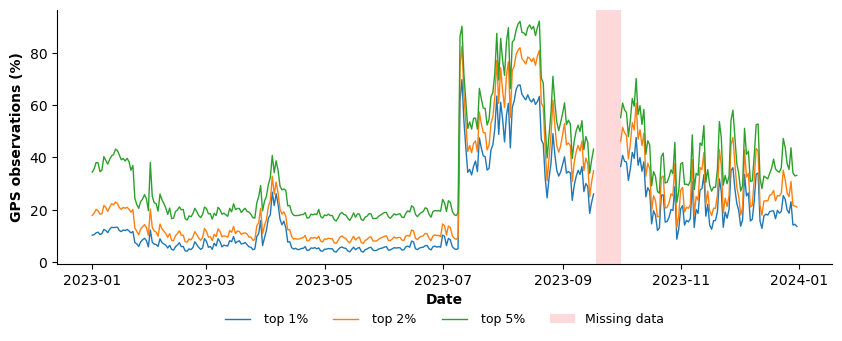

In [37]:
def top_pct_share(s):
    m = len(s)
    k = max(1, int(np.ceil(m * pct)))
    return s.nlargest(k).sum() / s.sum()


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3.3))

for pct in [0.01, 0.02, 0.05]:
    
    result = df_spatial.groupby("date")["n_points"].apply(top_pct_share).rename("share_pct").reset_index()

    x_share, y_share = fill_time_gaps(result["date"], result["share_pct"], freq="D")
    
    ax.plot(x_share,100*y_share, label=f" top {int(100*pct)}%", linewidth=1)

ax.set_xlabel("Date", weight=600);
ax.set_ylabel("GPS observations (%)", weight=600);
ax.axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0, label="Missing data")

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, frameon=False, fontsize=9);

**Figure 10.** Time series of the share of total GPS observations captured by the highest-ranked H3 hexagons at different thresholds: top 1% (blue), top 2% (orange), and top 5% (green) most visited hexagons.

The spatial distribution of GPS observations per hexagon reveals distinct patterns across the different data collection regimes in 2023. Figure X illustrates this by displaying the log-transformed number of points per hexagon for four representative periods: a reference period (May), the March interval (1–31 March), and two anomalous periods (9–12 July and 27 July–20 August).

During the baseline period, observations are fairly evenly spread across hexagons, indicating consistent spatial coverage. The March interval shows a general decrease in activity, with fewer points overall but a spatial distribution similar to the baseline, reflecting a proportional drop in visits rather than a change in visit concentration.

In contrast, the July–August intervals exhibit a pronounced spatial concentration of visits, with a small subset of hexagons accounting for a disproportionately large share of observations. Notably, these highly active hexagons largely overlap across the anomalous periods.

While some seasonal mobility variation is expected, the sharp changes observed here suggest that these patterns are more likely driven by shifts in data collection practices than by true changes in mobility behavior.

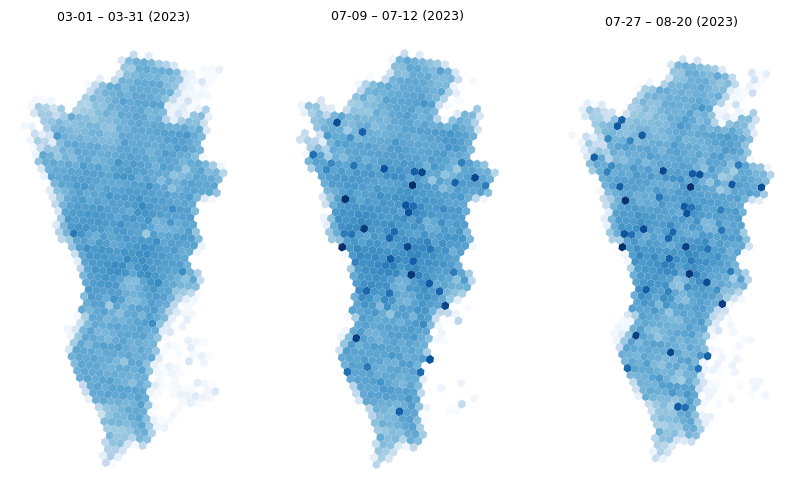

In [38]:
fig, axes = plt.subplots(nrows=1, ncols=len(unusual_ranges), figsize=(10, 6), sharex=False)

for ind_plot, date_plot in enumerate(unusual_ranges):

    

    df_hex_avg_points_day = df_spatial[df_spatial["date"].between(date_plot[0], date_plot[1])].groupby("hex_id", as_index=False).mean()
    gdf_map_spatial_coverage = gdf_h3.merge(df_hex_avg_points_day, left_on="h3_index", right_on="hex_id", how="left")
    gdf_map_spatial_coverage["n_points"] = gdf_map_spatial_coverage["n_points"].fillna(0)

    #print(gdf_map_spatial_coverage["n_points"].max()/1e6)
    label = f"{date_plot[0]:%m-%d} – {date_plot[1]:%m-%d} (2023)"
    
    _, _, cbar = plot_map_gdf(gdf_map_spatial_coverage, col="n_points", cmap="Blues", show_cbar=False,
                          vmin=1, fig=fig, ax=axes[ind_plot], cbar_orientation="vertical", vmax=10**6)

    axes[ind_plot].axis("off")
    axes[ind_plot].set_title(label, fontsize=9)

**Figure X.** Spatial distribution of the log₁₀-transformed number of GPS observations per hexagon for four selected periods in 2023: May (baseline), March, 9–12 July, and 27 July–20 August.

### 4.4 Spatial Representativeness

In [39]:
import rasterio
from rasterstats import zonal_stats

In [40]:
worldpop_path = "./shape_files/phl_pop_2023_CN_100m_R2025A_v1.tif"

# Load world pop raster
with rasterio.open(worldpop_path) as src:
    data = src.read(1)
    nodata = src.nodata
    raster_crs = src.crs

print("raster no data:", nodata)
print("raster crs:", raster_crs)

raster no data: -99999.0
raster crs: EPSG:4326


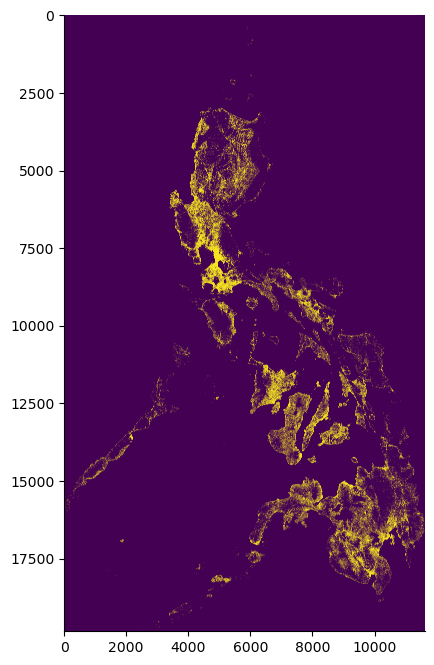

In [41]:
plt.figure(figsize=(10, 8))
plt.imshow(data, cmap="viridis")

In [42]:
avg_measures_per_hex = df_spatial.groupby(["hex_id"], as_index=False).mean()[["hex_id", "n_points", "n_users"]]

In [43]:
%%time

stats = zonal_stats(gdf_h3.geometry, worldpop_path, stats=["sum"], nodata=nodata, dtype="float64", all_touched=True)

gdf_h3["population"] = [0 if s["sum"] is None or s["sum"] < 0 else s["sum"] for s in stats]

CPU times: user 5.89 s, sys: 193 ms, total: 6.09 s
Wall time: 6.09 s


In [ ]:
gdf_h3[:1]

In [ ]:
#gdf_h3.to_file("./spatial_tessellations/gdf_h3_population.geojson", driver="GeoJSON")

In [ ]:
#gdf_h3 = gpd.read#_file("./spatial_tessellations/gdf_h3_population.geojson")

In [44]:
df_points_po = avg_measures_per_hex.merge(gdf_h3[['h3_index', 'population']],left_on='hex_id', right_on="h3_index", how='inner')

GPS observations are collected through GPS-enabled devices and therefore represent only a subset of the total population within the study area. Specifically, they capture individuals who own smartphones, have specific applications installed, and have enabled location-sharing permissions accessible to the data provider. Consequently, the derived mobility metrics should not be interpreted as measures of the true total population. Rather, they serve as high-frequency proxies for the spatial and temporal distribution of observed device users.

To assess spatial representativeness and identify potential representation bias, we examine the relationship between the **resident population** and **observed users** at the H3 hexagon level. Specifically, we correlate the average daily number of unique users per hexagon with the corresponding resident population counts (data extracted from [WorldPop](https://hub.worldpop.org/geodata/summary?id=74941)). At the aggregate level, population and observed users exhibit a strong positive association (Figure 11; Pearson's **r ≈ 0.62**), indicating that densely populated areas of the Manila metropolitan region tend to have higher numbers of observed users, though some spatial variability remains.

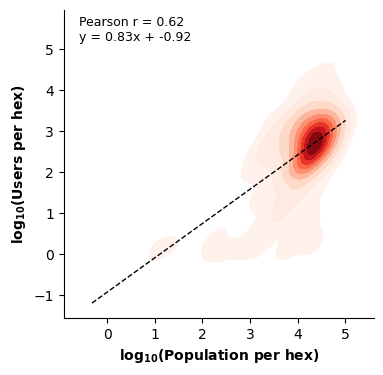

In [52]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))

# keep only positive values (for the log)
df_plot_xy = df_points_po[(df_points_po["population"] > 0) &(df_points_po["n_users"] > 0)]

# log10 transform
x = np.log10(df_plot_xy["population"])
y = np.log10(df_plot_xy["n_users"])

# scatter

sns.kdeplot(x=x, y=y, fill=True, cmap="Reds")
#plt.scatter(x=x, y=y, s=1)
ax.set_xlabel(r"$\mathbf{log_{10}}$(Population per hex)", weight=600)
ax.set_ylabel(r"$\mathbf{log_{10}}$(Users per hex)", weight=600)

# Pearson on log-log
pearson_corr, pearson_p = pearsonr(x, y)

# Linear fit in log-log space
slope, intercept = np.polyfit(x, y, 1)
# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='k', lw=1, linestyle="--")

# Pearson correlation and regression equation
pearson_text = f"Pearson r = {pearson_corr:.2f}\n" \
               f"y = {slope:.2f}x + {intercept:.2f}"

ax.text(0.05, 0.98, pearson_text, transform=ax.transAxes,
        fontsize=9, color="k", va="top", weight=400);

#ax.set_ylim(-0.5, None);
#ax.set_xlim(-0.5, None);

#print("Pearson r:", pearson_corr)
#print("p-value:", pearson_p)

**Figure 11.**
Bivariate kernel density plot of resident population estimates (WorldPop) versus the average daily number of unique users per H3 hexagon (Pearson correlation, *r* ≈ 0.62). The dashed line represents the linear fit. Red color intensity corresponds to higher point density.

### 4.5 Effects of User and Point Thresholds on Spatial Units

The hexagons within the Metro Manila area generally exhibit high activity in terms of GPS observations, with only a small proportion showing very low daily activity. As shown in Figure 14, on average, fewer than 1% of hexagons record one or fewer GPS points per day. This share increases to 1.4% for hexagons with two or fewer points, and 2.26% for those with five or fewer points.

<div style="text-align: center;">
  <div style="display: inline-block; max-width: 100%; overflow-x: auto; text-align: left;">
      
| Number of Points per Hex | Share of Hexes (%) |
| :----------------------: | :-------------------: |
| ≤ 1                      | 0.85 ± 0.47           |
| ≤ 2                      | 1.42 ± 0.64          |
| ≤ 5                      | 2.26 ± 0.77          |

</div>
</div>

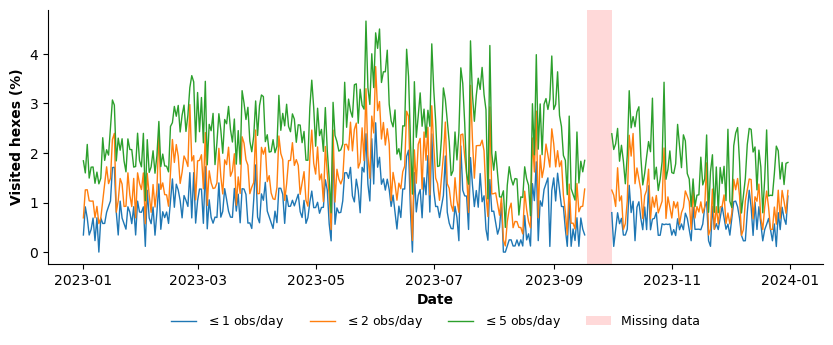

In [54]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3.3))

list_ths = [1,2,5]
for th in list_ths:

    v_noise_pct = 100*(df_spatial_daily_summary[f"n_hexes_points_le_{th}"]/df_spatial_daily_summary["n_hexes_active"])
    noise_avg = round(np.mean(v_noise_pct), 2)
    noise_std = round(np.std(v_noise_pct), 2)

    #print(f"hexes with <= {th} points {noise_avg} % (±{noise_std})")

    x_th, y_th = fill_time_gaps(df_spatial_daily_summary["date"], v_noise_pct.values, freq="D")
    
    ax.plot(x_th, y_th, label=f"$\leq${th} obs/day", linewidth=1)
    ax.set_xlabel("Date", weight=600);
    ax.set_ylabel("Visited hexes (%)", weight=600);

ax.axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0, label="Missing data")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, frameon=False, fontsize=9);

**Figure 14.**
Time series of the share of H3 hexagons recording ≤1 (blue), ≤2 (orange), and ≤5 (green) GPS points. The figure illustrates the proportion of low-activity hexagons over time.


In addition, only a small fraction of hexes is visited by very few unique users (Figure 15). On average, approximately 2.4% of hexes record visits from at most one user per day, increasing to 3.5% for ≤2 users and 4.2% for ≤3 users. This indicates that many spatial units are characterized by highly usage anf broad user participation, and just few hexagons are driven by a very small number of individuals rather than by broad user participation.

Moreover, only a small proportion of hexagons experience visits from very few unique users (Figure 15). On average, about 2.4% of hexagons record visits from no more than one user per day. This share increases to 3.5% for hexagons with two or fewer users, and 4.2% for those with three or fewer users. These findings suggest that most spatial units exhibit high levels of usage and broad user participation, with only a few hexagons being driven by a very small number of individuals rather than widespread user engagement. This is expected in a metropolitan area like Metro Manila, where urban areas typically have higher user engagement.

<div style="text-align: center;">
  <div style="display: inline-block; max-width: 100%; overflow-x: auto; text-align: left;">
      
| Number of Users per Hex| Share of Hexes (%) |
| :-------------------------:| :-------------------: |
| ≤ 1                        | 2.42 ± 0.68          |
| ≤ 2                        | 3.52 ± 0.77          |
| ≤ 3                        | 4.21 ± 0.99          |

</div>
</div>

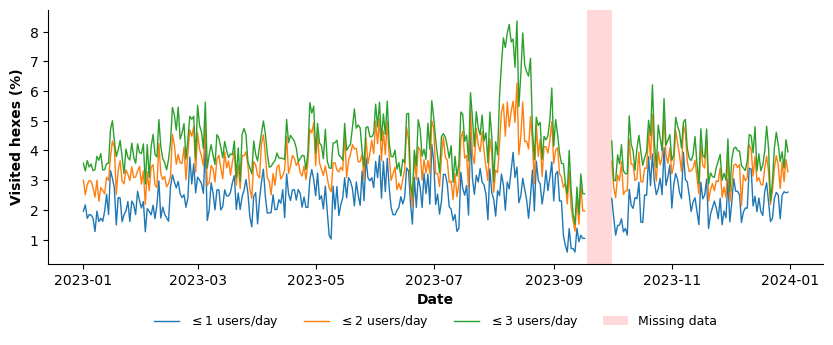

In [55]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3.3))

list_pcts = []
list_ths = [1,2,3]
for th in list_ths:

    v_noise_pct = 100*(df_spatial_daily_summary[f"n_hexes_users_le_{th}"]/df_spatial_daily_summary["n_hexes_active"])
    noise_avg = round(np.mean(v_noise_pct), 2)
    noise_std = round(np.std(v_noise_pct), 2)
    list_pcts.append(noise_avg)
    # print(f"hexes with <= {th} users {noise_avg} % (±{noise_std})")
    
    x_th, y_th = fill_time_gaps(df_spatial_daily_summary["date"], v_noise_pct.values, freq="D")
    ax.plot(x_th, y_th, label=f"$\leq${th} users/day", linewidth=1)
    
    ax.set_xlabel("Date", weight=600);
    ax.set_ylabel("Visited hexes (%)", weight=600);

ax.axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0, label="Missing data")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, frameon=False, fontsize=9);

**Figure 15.**
Time series of the share of H3 hexagons visited by ≤1 (blue), ≤2 (orange), and ≤5 (green) unique users.


### 4.6 Data Quality Implications

The spatial distribution of observations is consistent with expectations for a dense metropolitan area. Activity is observed across nearly the entire study region and is concentrated in highly populated urban locations. Areas with the lowest activity correspond primarily to natural areas and water bodies (e.g., La Mesa Watershed and Laguna de Bay). Observations over water bodies likely reflect movement-related activity (e.g., ferry or boat travel) rather than stationary presence and may be filtered depending on the analytical objective.

The distribution of visits across hexagons is skewed, with a small number of locations accounting for a large share of total observations (Gini coefficient ≈ 0.66). This heavy-tailed structure is typical of human mobility data and reflects the concentration of activity in highly attractive urban locations. As a result, simple averages can be dominated by high-activity areas, and distribution-aware statistics (e.g., medians, quantiles, or inequality measures) provide a more robust characterization of spatial patterns.

The positive correlation between resident population and observed users (Pearson’s r ≈ 0.62) suggests that the dataset captures the spatial distribution of activity reasonably well, with more densely populated areas generating higher numbers of observed users. This relationship supports the spatial representativeness of the dataset at an aggregate level, while also indicating that the data should be interpreted as a proxy for the distribution of observed device users rather than as a direct measure of the full resident population.

Some temporal intervals exhibit unusually strong spatial concentration of observations. In particular, during parts of July and August the share of activity captured by the most visited hexagons increases substantially, with the top 1% of hexes accounting for up to approximately 60% of all recorded observations. Such patterns likely reflect changes in sampling and should therefore be interpreted with caution.

Despite this concentration, most spatial units maintain relatively high daily activity levels. Only a small fraction of hexagons record very few observations or users per day, indicating that most cells in the metropolitan area are supported by a sufficiently large number of observations. This supports the use of relatively fine spatial resolutions for aggregate analyses within Metro Manila.

## 5. User Activity Assessment

This section examines the user-level dimension of the dataset by analyzing patterns of activity, spatial behavior, and contribution inequality across individuals. Specifically, we investigate the distribution of observations per user, the prevalence of sparse daily traces, and the extent to which user activity is spatially localized.

Given that our primary objective is to construct an Urban Space Index, we do not focus on individual mobility descriptors such as radius of gyration, nor do we attempt to characterize users’ mobility through detailed trajectory reconstruction. Instead, our analysis emphasizes aggregated behavioral patterns that are directly relevant to the proposed index.

In [110]:
dict_UDS_mean = df_user_daily_summary.mean().to_dict()
print("--- Averages per user per day ---")
print("measure")
print("avg. points:\t", round(dict_UDS_mean["avg_points"], 2))
print("avg. visits:\t", round(dict_UDS_mean["avg_hexes"], 2))
print("avg. time win:\t", round(dict_UDS_mean["avg_active_win"], 2), "min")

print()
dict_UDS_median = df_user_daily_summary.median().to_dict()
print("--- Medians per user per day ---")
print("p50 points:\t", round(dict_UDS_median["p50_points"], 2))
print("p50 visits:\t", round(dict_UDS_mean["p50_hexes"], 2))
print("p50 time win:\t", round(dict_UDS_mean["p50_active_win"], 2), "min")

--- Averages per user per day ---
measure
avg. points:	 22.75
avg. visits:	 2.21
avg. time win:	 357.44 min

--- Medians per user per day ---
p50 points:	 5.0
p50 visits:	 1.0
p50 time win:	 202.6 min


### 5.1 Total Points, Visited Hexes, and Active Window per User

User-level activity exhibits strong heterogeneity, as evident in Figure 16. The median user records approximately 5 GPS points, 1 visited location, and 203 minutes of observed activity per day, while mean values are higher: 23 GPS points, 2 locations, and 357 minutes. In general, a small share of highly active users accounts for most of the observations while the majority of users generate sparse, discontinuous daily traces.

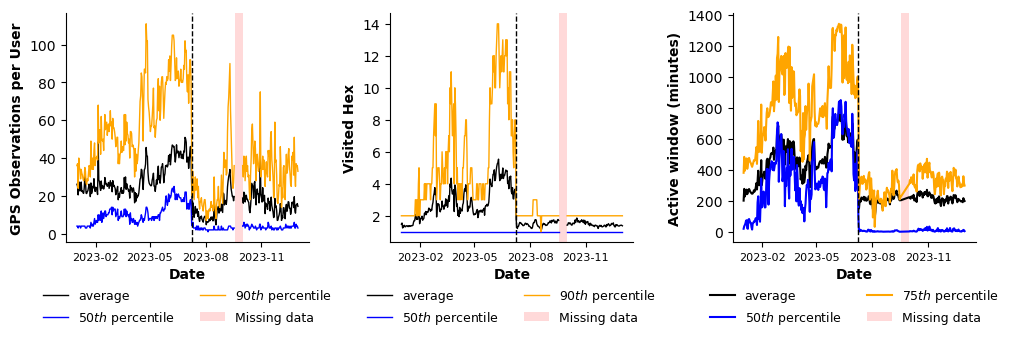

In [111]:
# Prepare subplot grid
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3.3),
                         constrained_layout=True, gridspec_kw={"hspace": 0, "wspace": -1})

# points
cols = ["avg_points", "p50_points", "p90_points"]
colors = ["k", "blue", "orange"]

for col, color in zip(cols, colors):
    if not "avg" in col:
        label = f"{int(col[1:3])}$th$ percentile" 
    else:
        label = "average"
    
    x_points, y_points = fill_time_gaps(df_user_daily_summary["date"], df_user_daily_summary[col], freq="D")
    axes[0].plot(x_points, y_points, c=color, label=label, linewidth=1)
axes[0].set_ylabel("GPS Observations per User", weight=600)

# visited hex
cols = ["avg_hexes", "p50_hexes", "p90_hexes"]
for col, color in zip(cols, colors):
    
    if "p" in col:
        label = f"{int(col[1:3])}$th$ percentile" 
    else:
        label = "average"
        
    x_hexes, y_hexes = fill_time_gaps(df_user_daily_summary["date"], df_user_daily_summary[col], freq="D")
    axes[1].plot(x_hexes, y_hexes, c=color, label=label, linewidth=1)
axes[1].set_ylabel("Visited Hex", weight=600)

# active win
cols = ["avg_active_win", "p50_active_win", "p75_active_win"]
for col, color in zip(cols, colors):
    if "p" in col:
        label = f"{int(col[1:3])}$th$ percentile" 
    else:
        label = "average"
        
    axes[2].plot(df_user_daily_summary["date"], df_user_daily_summary[col], c=color, label=label)
axes[2].set_ylabel("Active window (minutes)", weight=600)

#for ax in axes:
#    ax.axvspan(pd.to_datetime('2023-09-19'), pd.to_datetime('2023-09-29'),color='red', alpha=0.2)
#    ax.set_xlabel("Date", weight=600)
#    ax.legend()

for ax in axes:
    ax.axvline(pd.to_datetime("2023-07-10"), color="k", linestyle="--", linewidth=1)
    ax.axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0, label="Missing data")
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False, fontsize=9)
    ax.tick_params(axis='x', labelsize=8)
    ax.set_xlabel("Date", weight=600)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

**Figure 16.** Daily metrics per user: number of GPS points (left), number of visited hexagons (center), and active window duration in minutes (right). Lines show the mean or selected quantiles (50th, 75th, and 90th percentiles, as indicated). Shaded regions indicate periods with missing data.

As evident from Figure 16, the same intervals during which visits concentrate in a small number of hexagons also exhibit clear changes in the user-level metrics. In particular, these periods are characterized by a marked divergence between the median and the upper quantiles.  From 10 July onward, user-level values substantially decrease. In particular, upper quantiles flatten and overall variability declines, especially for the number of visited hexagons and active window duration. This pattern is consistent with a change in the data-generation process, likely reflecting an expansion in the user base combined with less intensive per-user tracking. As a result, user-level metrics are not directly comparable across periods and should be interpreted within homogeneous temporal regimes.

### 5.2 Inequality of Distribution of Observations across Users

We assess user‑level contribution patterns to evaluate the degree of user‑representation inequality in the dataset. The distribution of GPS observations across users is highly uneven: most users contribute relatively few observations, while a small fraction of highly active users accounts for a disproportionate share of all recorded points.

This imbalance is clearly visible in the rank-size distribution, which exhibits a pronounced heavy-tailed shape, indicating differences between low- and high-contributing users (Figure 17, left). Consistently, the Lorenz curve diverges from the equity line, with an associated Gini coefficient of 0.683, highligting strong concentration of observations among a small share of users (Figure 17, right).

From a data quality perspective, this pattern is typical of passively collected mobility data. However, it has important analytical implications, particularly for user‑weighted metrics and for any analysis that relies on individual‑level mobility intensity.

In [112]:
%%time
df_user_gb_avg = df_users.groupby(["uid"], as_index=False).agg(n_points=("n_points", "mean"))
df_user_gb_avg = df_user_gb_avg.sort_values("n_points", ascending=False)

CPU times: user 2min 14s, sys: 16.5 s, total: 2min 31s
Wall time: 2min 31s


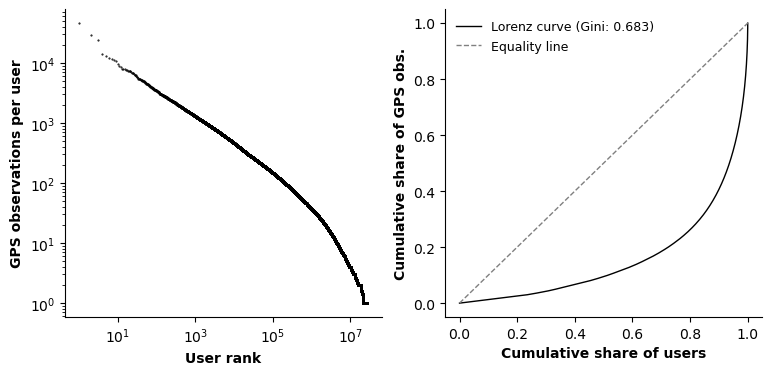

In [113]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

ranks = np.arange(1, len(df_user_gb_avg) + 1)
values = df_user_gb_avg["n_points"].values

#Rank–size plot (log–log)
axes[0].loglog(ranks, values, c="k", marker=".", linestyle="none", markersize=1)
axes[0].set_xlabel("User rank", weight=600)
axes[0].set_ylabel("GPS observations per user", weight=600)
#axes[0].set_title("Rank–size distribution of GPS points per user")

# Lorenz curve
values = np.sort(df_user_gb_avg["n_points"].values)
cum_points = np.cumsum(values)
cum_points = cum_points / cum_points[-1]

cum_users = np.arange(1, len(values) + 1) / len(values)
gini_score = round(gini(values), 3)
axes[1].plot(cum_users, cum_points, label=f"Lorenz curve (Gini: {gini_score})", c="k", linewidth=1)
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Equality line", linewidth=1)

axes[1].set_xlabel("Cumulative share of users", weight=600)
axes[1].set_ylabel("Cumulative share of GPS obs.", weight=600)
#axes[1].set_title("Lorenz curve of GPS points per user")
axes[1].legend(loc="upper left", fontsize=9);

#for ax in axes:
#    ax.set_aspect('equal')

**Figure 17.** Rank–size distribution of total GPS observations per user, showing a pronounced heavy-tailed distribution in individual activity levels (left).
Lorenz curve depicting the cumulative share of GPS observations by ranked users (right), with the corresponding Gini coefficient (0.683) quantifying inequality in user-level contribution to total activity.

### 5.3 Effects of Point and Hexes Thresholds on Users

A large share of users exhibit very sparse daily activity (Figure 18). On a typical day, approximately **19% of users generate at most one GPS point**, nearly **33% record two or fewer points**, and about **50% record five or fewer points**. This proportion increases to **64%** when considering users with **ten or fewer daily observations**.

These results indicate that most users contribute **limited and intermittent mobility traces**. As a result, trajectory-level analyses of individual mobility require restricting the sample to **high-quality users with sufficiently dense trajectories**, typically through strict filtering criteria. However, applying such filters would substantially reduce the number of retained users and may introduce **selection bias** in the resulting analyses.


<div style="text-align: center;">
  <div style="display: inline-block; max-width: 100%; overflow-x: auto; text-align: left;">
      
| Number of Points per User | Share of Users (%) |
| :------------------------:| :----------------: |
| ≤ 1                       | 19.05 ± 11.76     |
| ≤ 2                       | 33.13 ± 14.7      |
| ≤ 3                       | 40.32 ± 16.39      |
| ≤ 5                       | 50.67 ± 17.24      |
| ≤ 10                      | 64.42 ± 16.31      |

</div>
</div>

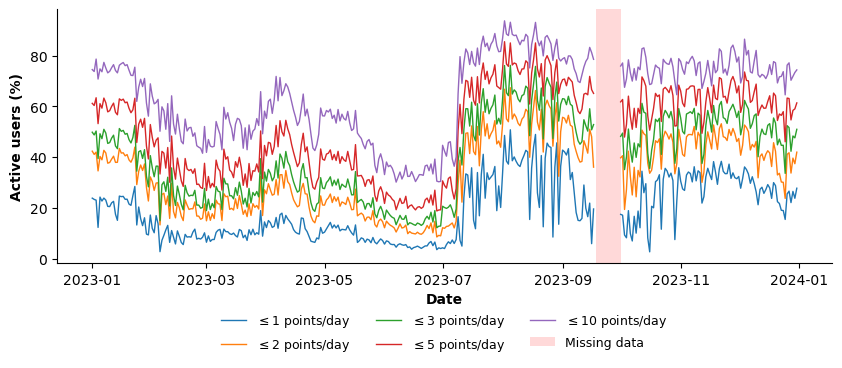

In [59]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3.3))

list_pcts = []
list_ths = [1,2,3,5,10]
for th in list_ths:

    v_noise_pct = 100*(df_user_daily_summary[f"n_users_le_{th}"]/df_user_daily_summary["n_users"])
    noise_avg = round(np.mean(v_noise_pct), 2)
    noise_std = round(np.std(v_noise_pct), 2)
    list_pcts.append(noise_avg)
    #print(f"users with <= {th} points {noise_avg} % (±{noise_std})")

    x_th, y_th = fill_time_gaps(df_user_daily_summary["date"], v_noise_pct.values, freq="D")
    ax.plot(x_th, y_th, label=f"$\leq${th} points/day", linewidth=1)
    
    ax.set_xlabel("Date", weight=600);
    ax.set_ylabel("Active users (%)", weight=600);


ax.axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0, label="Missing data")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False, fontsize=9);

**Figure 18.**
Daily percentage of users generating ≤1 (blue), ≤2 (orange), ≤3 (green), ≤5 (red), or ≤10 (purple) GPS observations. The shaded area denotes periods of missing data.


Most users are also spatially localized on a given day. On average, 73% of users visit at most one hex, and 87% visit two or fewer hexes. This pattern indicates that most daily activity reflects presence in a single location or a simple out-and-back pattern, rather than more complete trajectories. From a QA perspective, this behavior implies that user-level mobility metrics are likely to be data-sparse unless substantial temporal or spatial aggregation is applied, or minimum-activity thresholds are enforced (Figure 19). In addition, these results indicate that trajectory-level analyses should filter users not only by the number of GPS points but also by the number of visited hexagons. Many users may generate multiple observations within the same location, which provides little information about actual movement and therefore contributes limited value for trajectory-based mobility analyses.    

<div style="text-align: center;">
  <div style="display: inline-block; max-width: 100%; overflow-x: auto; text-align: left;">
      
| Number of Hexes per User| Share of Users (%) |
| :----------------------:| ------------------ |
| ≤ 1                     | 73.02 ± 9.32      |
| ≤ 2                     | 87.02 ± 8.21      |

</div>
</div>

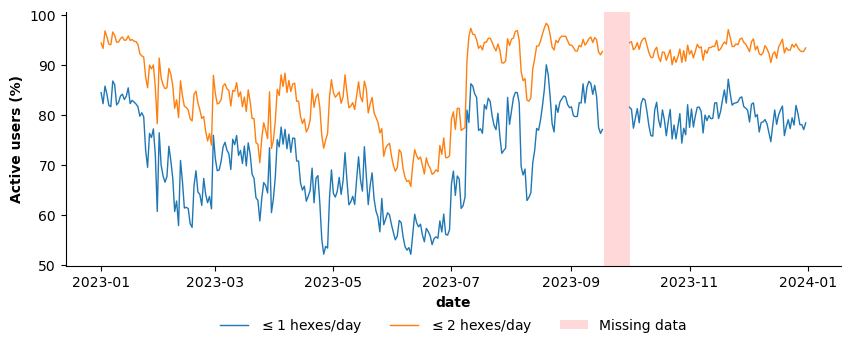

In [61]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3.3))

list_pcts = []
list_ths = [1,2]
for th in list_ths:

    v_noise_pct = 100*(df_user_daily_summary[f"n_users_hexes_le{th}"]/df_user_daily_summary["n_users"])
    noise_avg = round(np.mean(v_noise_pct), 2)
    noise_std = round(np.std(v_noise_pct), 2)
    list_pcts.append(noise_avg)
    #print(f"users with <= {th} hexes {noise_avg} % (±{noise_std})")

    x_th, y_th =  fill_time_gaps(df_user_daily_summary["date"], v_noise_pct.values, freq="D")
    ax.plot(x_th, y_th, label=f"$\leq${th} hexes/day", linewidth=1)
    
    ax.set_xlabel("date", weight=600);
    ax.set_ylabel("Active users (%)", weight=600);


ax.axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0, label="Missing data")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False);

**Figure 19.**
Daily percentage of users visiting ≤1 (blue) or ≤2 (orange) unique H3 hexagons. The shaded area denotes periods of missing data.


### 5.4 Data Quality Implications

User contributions follow a heavy-tailed distribution, meaning that averages are often dominated by a small subset of highly active users, while the behavior of low-activity users is under-represented. Where user-level comparability is required, analyses should rely on distribution-aware summaries (e.g., medians or quantiles) and stratify results by user activity level.

A large share of users generates sparse daily traces. On a typical day, about half of users record five or fewer GPS observations, and nearly two thirds record ten or fewer points. User activity is also highly localized, with approximately 73% of users visiting at most one hexagon per day and about 87% visiting no more than two. These patterns indicate that daily observations often reflect presence in a single location or simple movement behavior rather than multi-step trajectories.

From 10 July onward, there is a noticeable reduction in user-level activity. This change is consistent with a shift in the data-generation process and implies that user-level metrics are not directly comparable across periods.

Overall, these characteristics are consistent with passively collected mobility data. The dataset provides a robust signal of user presence and relative spatial activity, while detailed individual-level mobility metrics require substantial aggregation or filtering and should be interpreted within homogeneous temporal regimes.

## 6. Temporal Data Quality Assessment

This section examines the temporal dimension of the mobility dataset by analyzing daily activity levels, intra-day (hourly) patterns, and differences between weekdays and weekends. The analysis focuses on the evolution over time of the number of observations, active users, and visited spatial units, as well as on circadian mobility rhythms reflected in hourly distributions.
Taken together, these dimensions provide insight into the temporal stability and representativeness of the dataset and support the identification of temporal gaps, irregular sampling patterns, and structural changes in recording intensity that may affect downstream analyses.

### 6.1 Total Points, Unique Users, and Visited Hexes per Day

Figure 3 shows the daily evolution of GPS observations, active users, and visited hexagons. The time series reveals a clear structural break on 10 July 2023, after which the dataset transitions into distinct regimes characterized by different sampling properties.

**Baseline regime (January - 9th July)**

During the baseline period, the three indicators evolve consistently. The dataset records on average 5.9 million GPS points per day, 207k users, and ~869 visited hexes. Variability is relatively high for points and users (CV ≈ 57.6% and 67.5%), while spatial coverage remains stable (CV ≈ 1.4%), indicating a consistent spatial footprint despite fluctuations in activity levels. Importantly, variations in observations, users, and visited hexagons tend to move together, suggesting a relatively stable sampling regime. In this phase, increases in the number of users are generally accompanied by proportional increases in recorded observations and spatial coverage, indicating consistent data collection intensity.


**Sampling Shift (10th July).**

A clear structural break is observed on 10 July 2023, marking a shift in the data-generation process. On this date, both the number of GPS observations and active users increase abruptly relative to the preceding period, while the number of visited hexagons remains broadly stable. This divergence suggests a change in sampling intensity or user coverage instead of a sudden expansion in mobility. Accordingly, this date defines the boundary between the baseline regime and subsequent phases, and metrics before and after this point may not be not directly comparable without a proper normalization.



**T2) Post-shift regime (10th july - December)**

From 10 July onward, the dataset transitions into a new regime characterized by substantially higher activity levels compared to the baseline. On average, this period records approximately 21.6 million points and 1.33 million users per day, while the number of visited hexes remains broadly stable and comparable to baseline levels. Variability is moderate for points and users (CV ≈ 47.1% and 26.3%) and low for hexes (CV ≈ 1.2%), indicating a relatively stable spatial footprint.

**T1) Spatial concentration regime (27th July – 20th August).**

Within the post-shift period, a distinct phase of spatial concentration is observed. During this interval, both observations and users remain elevated (≈11.5 million points and 1.45 million users on average), while the number of visited hexes declines to approximately 826. At the same time, variability in points and users decreases (CV ≈ 33.3% and 25.1%), whereas spatial variability increases (CV ≈ 3.0%). This pattern indicates that activity becomes more concentrated in a smaller subset of locations, consistent with the spatial analyses in Section 4. The reduction in spatial coverage is therefore interpreted as a concentration effect rather than a decline in overall activity.


In conclusion, the first part of the year can be interpreted as a baseline regime. The second part reflects a different sampling regime, beginning on 10 July, with higher activity levels and an intermediate phase of spatial concentration. As a result, temporal comparisons across these periods should be conducted with caution and require appropriate normalization or regime-specific analysis. 
 
 
 
<div style="text-align: center;">
  <div style="display: inline-block; max-width: 100%; overflow-x: auto; text-align: left;">
    
| **Regime**                                         | **Main Signal**                               | **Primary Driver**                                | **Usability**                   | **CV Points (%)** | **CV Users (%)** | **CV Hexes (%)** |
| -------------------------------------------------- | --------------------------------------------- | ------------------------------------------------- | ------------------------------- | ----------------- | ---------------- | ---------------- |
| **Baseline** (Jan 2 - Jul 9)                       | Stable co-movement across metrics             | Stable sampling regime                            | High                            | **57.6**          | **67.5**         | **1.4**          |
| **T2) Post-shift** (Jul 10 - Dec)                 | Higher volume, stable spatial footprint       | Increased sampling intensity / expanded user base | Medium (requires normalization) | **47.1**          | **26.3**         | **1.2**          |
|  **T1) Spatial Concentration** (Jul 27 - Aug 20) | Elevated activity concentrated in fewer hexes | Sampling shift with spatial concentration         | Medium-Low (use with caution)   | **33.3**          | **25.1**         | **3.0**          |


</div>
</div>

In [ ]:
def rel_change(value, base):
    
    return 100*(value-base)/base

In [ ]:
rel_change(value=11199454.47, base=2284755.67)

In [17]:
# The ranges are inclusive, i.e., [a, b]
dict_out_intervals = {
    "T1": ["2023-07-27", "2023-08-20"],
      "T2": ["2023-07-10", "2023-12-31"],
  
}
                            
dict_interval_color = {
"T1":"blue",
"T2":"orange",
}

dict_interval_name = {
 "T1":"T1) Spatial Concentration",
"T2": "T2) Post-shift"}


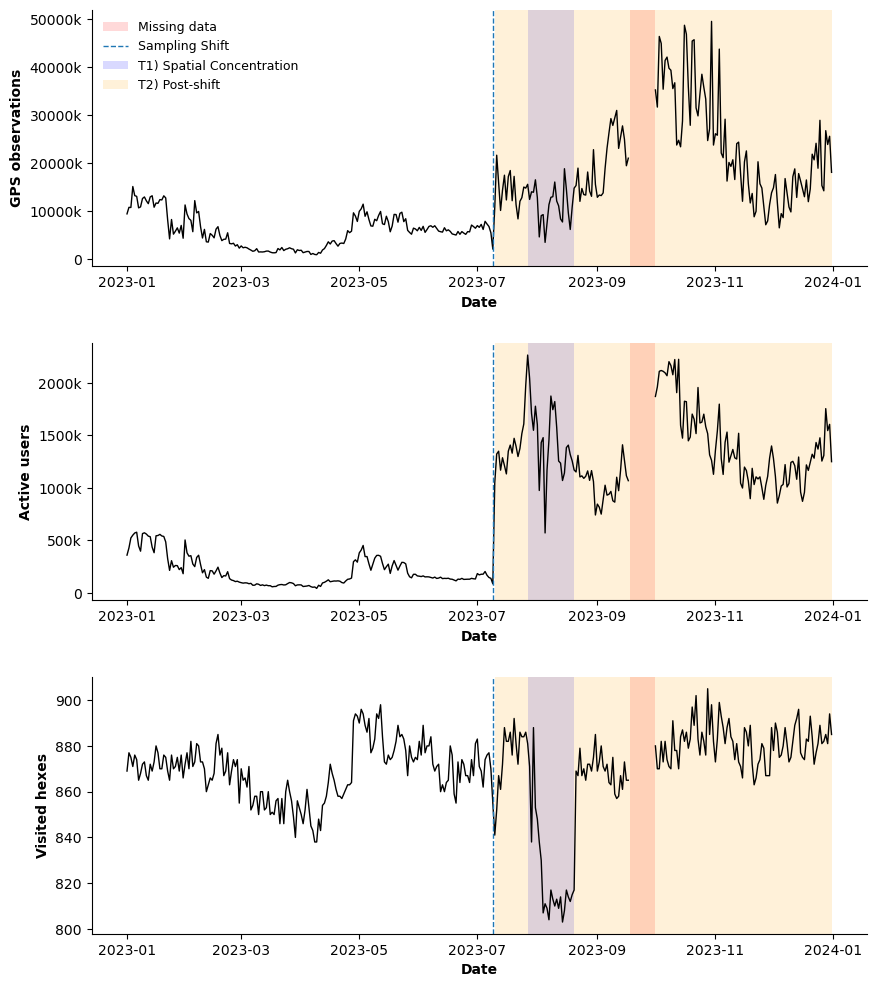

In [105]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=False, gridspec_kw={'hspace': 0.3})

x_points, y_points = fill_time_gaps(df_user_daily_summary["date"], df_user_daily_summary["n_points"], freq="D")
axes[0].plot(x_points, y_points, c="k", linewidth=1)
axes[0].set_ylabel("GPS observations", weight=600);

x_users, y_users = fill_time_gaps(df_user_daily_summary["date"], df_user_daily_summary["n_users"], freq="D")
axes[1].plot(x_users, y_users, c="k", linewidth=1)
axes[1].set_ylabel("Active users", weight=600);

x_hexes, y_hexes = fill_time_gaps(df_spatial_daily_summary["date"], df_spatial_daily_summary["n_hexes_active"], freq="D")
axes[2].plot(x_hexes, y_hexes, c="k", linewidth=1)
axes[2].set_ylabel("Visited hexes", weight=600);

for ax in axes:
    ax.set_xlabel("Date", weight=600);
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(thousands_formatter))
    
    ax.axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0, label="Missing data")
    ax.axvline(pd.to_datetime("2023-07-09"), linestyle="--", linewidth=1, label="Sampling Shift")
    
    for interval_name, (interval_start, interval_end) in dict_out_intervals.items():
        ax.axvspan(pd.to_datetime(interval_end),
                   pd.to_datetime(interval_start),
                   color=dict_interval_color[interval_name],
                   alpha=0.15, linewidth=0, label=dict_interval_name[interval_name])

axes[0].legend(fontsize=9);

In [ ]:
#### Dynamic version of the previous one (to zoom in)
plotly_fig = tls.mpl_to_plotly(fig)
#plotly_fig.show()
plotly_fig.write_html("time_series_plot.html")

**Figure 3.** Daily time series of total GPS observations (top), number of unique active users (middle), and number of visited spatial units at H3 resolution 7 (bottom). Shaded regions indicate data regimes: baseline period (white), Dense-User Tracking Period (T1; orange), User-Drop Period (T2; blue), missing data interval (red), and Year-End Surge (T3; green).

In [11]:
def split_by_periods(df, periods, date_col):
    
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    # Ensure periods are datetime
    periods = [(pd.to_datetime(start), pd.to_datetime(end)) 
               for start, end in periods]

    # Collect period DataFrames
    period_dfs = []
    combined_mask = pd.Series(False, index=df.index)

    for start, end in periods:
        mask = (df[date_col] >= start) & (df[date_col] <= end)
        period_dfs.append(df.loc[mask])
        combined_mask |= mask

    # Baseline = not in any period
    baseline_df = df.loc[~combined_mask]

    return period_dfs, baseline_df

#### Relationships among Total GPS Points, Unique Users, and Unique Visited Hexes

To evaluate how the relationships among total GPS observations, active users, and visited hexagons evolve over time, we compare their daily correlations across the baseline period, the post-shift regime (T2), and the spatial concentration phase (T1). The three periods form distinct clusters of points, each corresponding to a different data sampling regime. 

During the **baseline period** (black points), the three dimensions exhibit a compact and consistent scaling structure. GPS observations increase strongly with the number of users (r ≈ 0.92) and with visited hexagons (r ≈ 0.68). The relationship between users and visited hexagons is moderate (r ≈ 0.55), suggesting as expected that additional users tend to concentrate within already active areas rather than expanding spatial coverage.

In the **post-shift regime (T2)** (orange points), the relationships become more dispersed as the number of points and users increases. While GPS observations still increase with the number of users (r ≈ 0.68), the association between users and visited hexagons becomes substantially weaker (r ≈ 0.25). This indicates that increases in user counts are less systematically associated with broader spatial coverage. The relationship between observations and visited hexagons also weakens (r ≈ 0.21), suggesting a decoupling between overall activity volume and spatial extent.

The **spatial concentration phase (T1) (blue points)** exhibits a distinct pattern. The relationship between users and observations remains moderate (r ≈ 0.61), but the association between visited hexagons and the other metrics is substantially weaker (r ≈ 0.31 with observations). This reflects a regime in which activity becomes concentrated in a smaller subset of locations, with high volumes of observations generated without a corresponding expansion in spatial coverage.

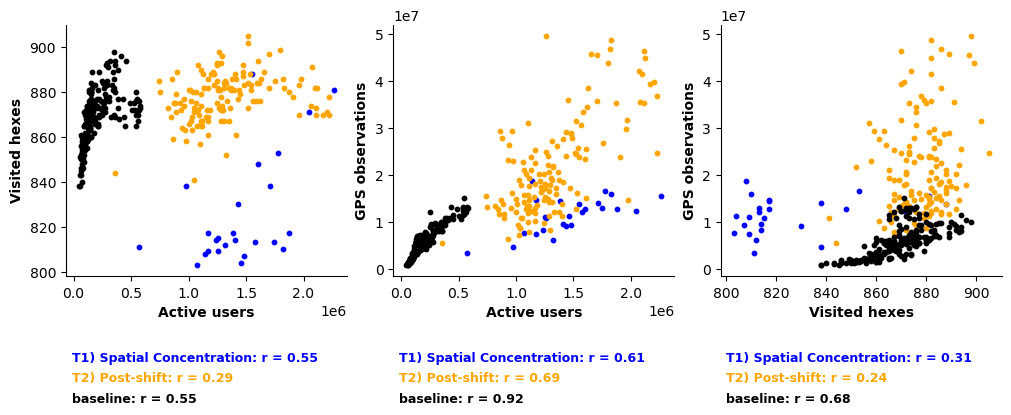

In [18]:
period_df_user, baseline_df_user = split_by_periods(df_user_daily_summary, list(dict_out_intervals.values()), "date")
period_df_spatial, baseline_df_spatial = split_by_periods(df_spatial_daily_summary, list(dict_out_intervals.values()), "date")

# subtract the concentration pattern from the post 9th july dataset
period_df_user[1] = period_df_user[1][~period_df_user[1]["date"].between(period_df_user[0]["date"].min(), period_df_user[0]["date"].max())]
period_df_spatial[1] = period_df_spatial[1][~period_df_spatial[1]["date"].between(period_df_spatial[0]["date"].min(), period_df_spatial[0]["date"].max())]




measure_to_label = {"n_users": "Active users",
                    "n_hexes": "Visited hexes",
                   "n_hexes_active": "Visited hexes",
                   "n_points": "GPS observations"}


# Prepare subplot grid
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 4),
                         constrained_layout=True, gridspec_kw={"hspace": 0.1, "wspace": 0})

pairs = list(combinations(["n_users", "n_hexes_active", "n_points"], 2))

for ind_measure, (m1, m2) in enumerate(pairs):

    ax = axes[ind_measure]
    corrs = []

    ax.set_xlabel(measure_to_label[m1], weight=600)
    ax.set_ylabel(measure_to_label[m2], weight=600)

    for ind_interval, interval_name in enumerate(dict_out_intervals.keys()):
        if m1 == "n_hexes_active":
            x = period_df_spatial[ind_interval][m1]
        else:
            x = period_df_user[ind_interval][m1]

        if m2 == "n_hexes_active":
            y = period_df_spatial[ind_interval][m2]
        else:
            y = period_df_user[ind_interval][m2]

        ax.scatter(x, y, s=10, alpha=1, label=interval_name, color=dict_interval_color[interval_name])
        # Pearson correlation
        r = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan
        corrs.append((dict_interval_name[interval_name], r, dict_interval_color[interval_name]))


    # plot the baseline
    if m1 == "n_hexes_active":
        x = baseline_df_spatial[m1]
    else:
        x = baseline_df_user[m1]

    if m2 == "n_hexes_active":
        y = baseline_df_spatial[m2]
    else:
        y = baseline_df_user[m2]

    ax.scatter(x, y, s=10, alpha=1, label="baseline", c="k")
    # Pearson correlation
    r = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan
    corrs.append(("baseline", r, "k"))

        

    # annotate inside plot (top-left corner)
    y_pos = -0.3
    for label, r, color in corrs:
        ax.text(
            0.02, y_pos,
            f"{label}: r = {r:.2f}",
            transform=ax.transAxes,
            fontsize=9,
            color=color,
            va="top",
            weight=600,
        )
        y_pos -= 0.08
        


**Figure 4.** Scatter plots illustrating the daily relationships among total GPS observations, number of unique users, and number of visited hexagons. Points are color-coded by regime (baseline, T1, T2, T3) to highlight differences in scaling patterns across periods.

In [108]:
for measure in ["n_points", "n_hexes_active",  "n_users"]:
    print(measure)

    #baseline
    if measure == "n_hexes_active":
        x_base = baseline_df_spatial[measure]
    else:
        x_base = baseline_df_user[measure]

    print("baseline", round(np.mean(x_base), 2))
    
    for ind_interval, interval_name in enumerate(dict_out_intervals.keys()):
        if measure == "n_hexes_active":
            x = period_df_spatial[ind_interval][measure]
        else:
            x = period_df_user[ind_interval][measure]

        print(dict_interval_name[interval_name], round(np.mean(x), 2))
    print()


n_points
baseline 5898422.41
T1) Spatial Concentration 11461987.72
T2) Post-shift 21573301.34

n_hexes_active
baseline 868.81
T1) Spatial Concentration 825.6
T2) Post-shift 878.08

n_users
baseline 207345.27
T1) Spatial Concentration 1452035.4
T2) Post-shift 1328854.1



In [109]:
def coefficient_of_variation(data):
    data = np.array(data)
    mean = np.mean(data)
    if mean == 0:
        return np.nan  # Avoid division by zero
    std_dev = np.std(data, ddof=1)  # sample standard deviation
    cv = (std_dev / mean) * 100
    return cv



for measure in ["n_points", "n_hexes_active",  "n_users"]:
    print(measure)

    #baseline
    if measure == "n_hexes_active":
        x_base = baseline_df_spatial[measure]
    else:
        x_base = baseline_df_user[measure]

    cv = coefficient_of_variation(x_base)
    print("baseline", round(cv, 2))
    
    for ind_interval, interval_name in enumerate(dict_out_intervals.keys()):
        if measure == "n_hexes_active":
            x = period_df_spatial[ind_interval][measure]
        else:
            x = period_df_user[ind_interval][measure]

        cv = coefficient_of_variation(x)
        print(dict_interval_name[interval_name], round(cv, 2))
    print()


n_points
baseline 57.56
T1) Spatial Concentration 33.28
T2) Post-shift 47.1

n_hexes_active
baseline 1.39
T1) Spatial Concentration 2.96
T2) Post-shift 1.17

n_users
baseline 67.54
T1) Spatial Concentration 25.08
T2) Post-shift 26.27



### 6.2 Circadian Rhythm: Hour-of-day Distributions

The hour-of-day distributions of points, active users, and active spatial hexes exhibit a clear **circadian pattern**, as shown in Figure 5. Activity is lowest during nighttime hours, increases in the early morning, remains relatively stable from late morning through early evening, and gradually declines thereafter. The consistency of these daily profiles across indicators provides an important quality check, suggesting that, despite temporal fluctuations in data volume, the dataset captures realistic daily mobility rhythms {cite}`jiang2016timegeo`.

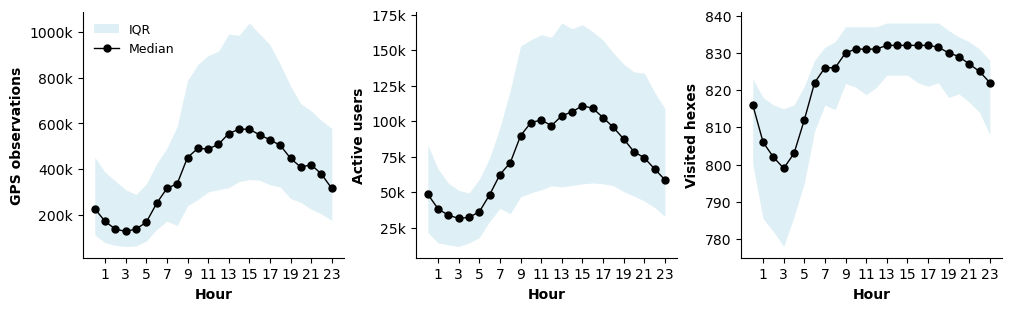

In [101]:
_, axes = plot_hourly_profiles(df_temporal, center="median", show_iqr=True, figsize=(10,3));

for ax in axes:
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(thousands_formatter))

axes[0].legend(fontsize=9);

**Figure 5.** Average hourly distribution of total GPS observations, unique users, and active hexagons across all available days in 2023 (local time). Values are aggregated across the full observation period.

### 6.3 Weekend vs. Weekday

We also investigate how mobility and activity patterns differ between weekdays and weekends (Figure 6). Weekdays exhibit a higher volume of observations (on average, +15%) and a greater number of users (on average, +18%) compared to weekends. However, the number of visited areas remains largely consistent across weekdays and weekends, with only a negligible increase on weekdays (+0.14%).

In [80]:
temporal_daily_stats = df_temporal.copy()
temporal_daily_stats["dow"] = pd.to_datetime(temporal_daily_stats["date"]).dt.dayofweek # Mon=0 ... Sun=6
temporal_daily_stats["is_weekend"] = temporal_daily_stats["dow"] >= 5

In [81]:
measure_to_label = {"n_users": "Active users",
                    "n_hexes": "Visited hexes",
                   "n_hexes_active": "Visited hexes",
                   "n_points": "GPS observations"}


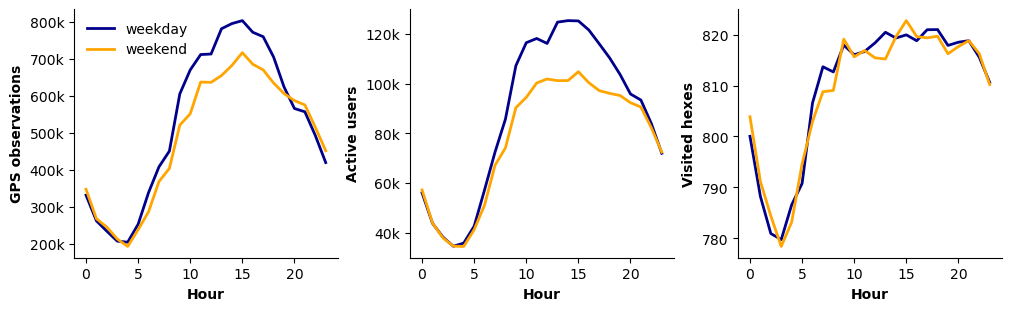

In [82]:
list_measures = ['n_points', 'n_users', 'n_hexes']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3),
                         constrained_layout=True, gridspec_kw={ "hspace": 0.1,"wspace": 0})

for ind_measure, measure in enumerate(list_measures):

    gb_week_vs_wend = temporal_daily_stats.groupby(["is_weekend", "hour"])[[measure]].mean().reset_index()

    for is_we, lab, col in [(False, "weekday", "darkblue"), (True, "weekend", "orange")]:
        gb_plot = gb_week_vs_wend[gb_week_vs_wend["is_weekend"] == is_we].sort_values("hour")
        axes[ind_measure].plot(gb_plot["hour"], gb_plot[measure], label=lab, color=col, linewidth=2)

    axes[ind_measure].set_ylabel(measure_to_label[measure], weight=600)
    axes[ind_measure].set_xlabel("Hour", weight=600)

for ax in axes:
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(thousands_formatter))

axes[0].legend();

**Figure 6.** Comparison of mean hourly GPS observations between weekdays and weekends, aggregated over the study period. Curves reflect differences in intra-day activity profiles.

We further examined whether weekday–weekend differences are reflected in the total number of observations, users, and visited hexes within the same week.

To assess this, for each week we compared the total number of observations, users, and hexes recorded on weekdays versus weekends and computed the relative percentage difference. The results indicate that the number of observations and users is significantly higher on weekdays than on weekends. Statistical tests confirm these differences (observations: [Wilcoxon](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html) ($p \approx 6.9 \cdot 10^{-4}$), t-test ($p \approx 6.4 \cdot 10^{-4}$); users: Wilcoxon ($p \approx 2.37 \cdot 10^{-6}$), [t-test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html) ($p \approx 2.57 \cdot 10^{-5}$)).

In contrast, the number of visited hexes does not show a statistically significant difference between weekdays and weekends (Wilcoxon ($p \approx 0.566$); t-test ($p \approx 0.517$)), indicating that while activity levels and user participation vary across the week, the spatial coverage of visited areas remains largely consistent.

In [83]:
df_tmp_sum = temporal_daily_stats.groupby("date", as_index=False).sum()

In [84]:
df_tmp_sum["num_week"] = df_tmp_sum["date"].apply(lambda x: x.weekofyear)
df_tmp_sum["is_weekend"] = df_tmp_sum["is_weekend"].apply(lambda x: int(x>0))
df_tmp_sum = df_tmp_sum[1:]

df_tmp_sum[:3]

,date,hour,n_points,n_users,n_hexes,dow,is_weekend,num_week
1,2023-01-02,276,10778689,1228317,19607,0,0,1
2,2023-01-03,276,10749308,1319091,19563,24,0,1
3,2023-01-04,276,15111115,1508018,19432,48,0,1


In [ ]:

variable_stat = "n_hexes"

df_pivot = df_tmp_sum.groupby(["num_week", "is_weekend"])[[variable_stat]].mean().unstack("is_weekend")
df_pivot["pct_diff"] = (
    100*(df_pivot[(variable_stat, 0)] - df_pivot[(variable_stat, 1)]) 
    / df_pivot[(variable_stat, 1)]
)

df_pivot = df_pivot.dropna()

In [ ]:
df_pivot["pct_diff"].mean(), df_pivot["pct_diff"].median()

In [ ]:
from scipy.stats import ttest_1samp

ttest_1samp(df_pivot["pct_diff"], 0)

In [ ]:
from scipy.stats import wilcoxon

wilcoxon(df_pivot["pct_diff"])

points,  (Wilcoxon p ≈ 0.00069; t-test p ≈ 0.00064).
n_users Wilcoxon p ≈ 2.36936675790389e-06; t-test p ≈ 2.573855449774003e-05).
n_hexes (Wilcoxon p ≈ 0.5655778099255286; t-test p ≈ 0.5167079272903838).


### 6.4 Data Quality Implications

The temporal patterns observed in user counts, observation volumes, and spatial coverage highlight several important considerations for data quality and interpretation. In particular, variations in recorded activity are partly driven by changes in the data-generation process rather than solely by underlying mobility dynamics.


First, the structural break observed on 10 July indicates a shift in sampling intensity or user coverage. Both GPS observations and active users increase abruptly, while spatial coverage remains broadly stable. This pattern is unlikely to reflect a sudden change in mobility behavior and instead suggests modifications in the data collection process (e.g., changes in application coverage or data ingestion). As a result, absolute activity levels before and after this transition are not directly comparable without normalization.

Second, during the spatial concentration phase, the number of visited hexagons declines while the number of active users remains high. This indicates that observations become concentrated in a smaller subset of locations rather than reflecting a reduction in overall activity. Metrics based on spatial coverage or per-area averages are therefore sensitive to this effect and should be interpreted with caution during this interval.

The September data gap, further limitis the reliability of longitudinal indicators. Temporal comparisons spanning this phase should be avoided unless explicit adjustments are applied. We recommend treating September 18–30 as structurally missing and avoiding interpolation across this period, as it introduces a discontinuity in the data-generating process that may bias longitudinal comparisons.

The dataset also reproduces well-established temporal mobility rhythms, showing a clear circadian pattern. In addition, weekday activity levels are higher than those observed on weekends as confirmed by statistical tests. While these patterns support the internal validity of the dataset and indicate that it captures realistic daily mobility dynamics, they also imply that comparisons across hours, days, or day types should be interpreted cautiously, as observed differences may reflect structural temporal rhythms rather than behavioral change.


In summary, for a robust temporal analysis, longitudinal analyses should either exclude anomalous periods or normalize metrics by active-user counts to reduce sensitivity to changes in sampling intensity.

## 7. Data Quality Assessment Summary

This assessment evaluated the temporal, spatial, and user-level properties of the mobility dataset to determine its suitability for constructing an Urban Space Usage Index.

Overall, the dataset provides broad coverage of Metro Manila and internally consistent aggregate signals. At the same time, it exhibits structural unevenness across time, space, and users that directly affects how indicators should be constructed and interpreted.

### 7.1 Temporal Dimension

The dataset achieves **high temporal coverage (96.62%) over 2023**. Daily patterns of observations, active users, and visited spatial units remain broadly stable during most of the observation period, although the time series exhibits a structural break on **10 July**, followed by a phase of increased spatial concentration of observations and a data interruption in September.

These changes are more consistent with variations in the data-generation process than with behavioral mobility shifts and therefore limit direct longitudinal comparability. Raw time-series comparisons across periods with different sampling characteristics are not valid without normalization.

For index construction, temporally homogeneous regimes should be identified and treated consistently. Periods affected by changes in sampling intensity, spatial concentration, or missing data should either be excluded or explicitly modeled.

### 7.2 Spatial Dimension

Spatial coverage across the Metro Manila study area is extensive (**99.52%** of H3 cells record at least one observation during the year). Activity, as expected, follows a heavy-tailed distribution, with a small fraction of spatial units accounting for a disproportionate share of total observations.

Temporal analyses further reveal intervals during which observations become unusually concentrated in a limited number of locations, indicating changes in the spatial distribution of recorded activity instead of changes in mobility levels. During these periods, a small subset of highly visited hexagons captures a large share of total observations.

These characteristics are expected from passively collected mobility data and do not invalidate the dataset, but spatial indicators should rely on distribution-aware statistics and that periods of extreme spatial concentration should be treated with caution in downstream analyses.

### 7.3 User Dimension

User contributions are highly heterogeneous. A small subset of highly active users accounts for a large share of observations, while most users produce sparse and localized daily traces: approximately 50% of users generate five or fewer observations per day.

From 10 July onward, user activity becomes more homogeneous, with a noticeable flattening of user-level distributions and reduced variability. This pattern is consistent with a shift in the data-generation process, possibly reflecting changes in user composition and/or tracking intensity.

This structure limits the robustness of individual-level mobility metrics and trajectory-based indicators without substantial aggregation or filtering. While trajectory analyses remain possible when restricting the sample to users with sufficiently dense activity traces, aggregate presence-based measures at the spatial-unit level provide a more stable signal of activity and are therefore more appropriate for index construction.

### 7.4 Overall Assessment

<div style="color: red">

OLD VERSION (WAS FOR TURKEY)
    
The dataset is suitable for constructing an Urban Space Usage Index when interpreted as a signal of relative presence and activity rather than as a comprehensive representation of individual mobility behavior.

Its principal strengths include large-scale coverage and stable aggregate dynamics within identified regimes. Its primary limitations arise from time-varying sampling intensity, uneven spatial representation, and user-level sparsity.


Accordingly, index construction should:

- Rely on temporally stable regimes or apply normalization across regimes;

- Apply spatial aggregation or population-aware adjustments in low-activity areas;

- Avoid reliance on individual-level trajectory metrics;

- Treat any annual baseline with caution, ensuring that structural regime shifts are explicitly accounted for.

When these safeguards are implemented, the dataset provides a reliable foundation for high-frequency monitoring of urban space usage.

</div>

#### Suitable and Non-Suitable Applications

<div style="color: red">

OLD VERSION (WAS FOR TURKEY)
    
**Suitable Applications**

The dataset is well-suited for:

- Aggregate, presence-based indicators of urban space usage

- Relative comparisons across locations within similar coverage regimes

- Urban and peri-urban analyses at daily or coarser temporal resolution

- Event- or shock-related analyses, provided anomalous periods are explicitly handled


**Non-Suitable Applications**

Without substantial aggregation or correction, the dataset is not well-suited for:

- Individual-level mobility profiling or behavioral inference

- Fine-grained trajectory reconstruction or detailed OD analysis

- Rural mobility indicators

- Longitudinal comparisons that assume stable sampling intensity over time

</div>


| **DO**                                                                                                                                                                                                                      | **DON’T**                                                                                                                                                                                         |
| --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Aggregate and smooth temporally** (for example, weekly or monthly aggregation; rolling averages) and **analyze within homogeneous data regimes** (baseline versus T1, T2, T3).                                            | **Do not attribute peaks or drops as real mobility effects** before verifying that they are not driven by tracking intensity, ingestion changes, or missing data periods.                 |
| **Interpret temporal trends jointly with diagnostic indicators** (active users, points per user, users per hex, regime flags) and explicitly document excluded or adjusted periods.                                         | **Do not attribute daily or short-term fluctuations to behavioral change** without normalizing for coverage variation and verifying regime stability.         
| **Use presence-based or relative metrics** (for example, active users per hex, share of total activity, standardized change relative to a local baseline) to improve comparability.                                         | **Do not treat raw point counts as measures of mobility volume** or as direct proxies for total population activity.                                                                              |
| **Correct for uneven spatial coverage** through population-aware normalization, stratification by urbanization level, or reporting per-capita or per-device rates.                                                          | **Do not compare raw mobility levels across regions**, particularly between urban and rural areas, without adjusting for sampling intensity and coverage differences.                             |
| **Match spatial resolution to data density** by applying finer H3 levels only where user density is sufficient and aggregating rural or peripheral areas to coarser spatial units when necessary.                           | **Do not conduct fine-grained spatial inference** in cells where daily activity is extremely low (for example, one or fewer users), as results will be statistically unstable and outlier-driven. |
| **For trajectory- or origin-destination-based analyses, enforce minimum data sufficiency thresholds** (for example, minimum number of points per day or minimum active window) and report sensitivity to threshold choices. | **Do not compute individual-level mobility or origin-destination metrics on sparse traces**, and do not apply aggressive filtering without explicitly assessing potential selection bias.         |

____

## 8. References

```{bibliography}
:style: unsrt
```